# Steel CHI

## Imports

In [1]:
import warnings
warnings.filterwarnings("ignore") 
import logging
logging.disable(logging.CRITICAL)
import os
import time
import ast

%load_ext autoreload
%autoreload 2

import openpyxl
from openpyxl import load_workbook
from tqdm import tqdm_notebook as tqdm

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns
import statsmodels.api as sm
import scikit_posthocs as sp
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import RobustScaler
from scipy.stats import shapiro, levene, ks_2samp
from scipy.stats import friedmanchisquare, rankdata, f_oneway
from scipy.stats import norm, t as student_t, chi2
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from arch import arch_model
from autorank import autorank, plot_stats
from typing import Optional

from darts import TimeSeries
from darts.models import ExponentialSmoothing, ARIMA, LinearRegressionModel, RNNModel, TransformerModel, NHiTSModel, TCNModel, DLinearModel, TSMixerModel
from darts.utils.likelihood_models.torch import GaussianLikelihood, QuantileRegression
from darts.utils.callbacks import TFMProgressBar
import darts.utils.timeseries_generation as tg
from darts.utils.timeseries_generation import sine_timeseries, gaussian_timeseries, constant_timeseries
from darts.metrics import mae, mse, rmse, mape, smape, mase, rmsle, marre
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pytorch_lightning.callbacks.early_stopping import EarlyStopping

import optuna
from optuna import Trial, create_study


## Torch Preparation

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import shutil
from sklearn.preprocessing import MinMaxScaler
from tensorboardX import SummaryWriter
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def generate_torch_kwargs():
    # run torch models on CPU, and disable progress bars for all model stages except training.
    return {
        "pl_trainer_kwargs": {
            "callbacks": [TFMProgressBar(enable_train_bar_only=True)],
        }
    }


torch_kwargs = {}
if "generate_torch_kwargs" in globals() and callable(globals()["generate_torch_kwargs"]):
    try:
        torch_kwargs = generate_torch_kwargs()
    except Exception:
        torch_kwargs = {}



# Global seeds
torch.manual_seed(42)
import random
np.random.seed(42)
random.seed(42)

# For GPU using
torch.cuda.manual_seed(42)
torch.cuda.manual_seed_all(42)

## Pre-Processing

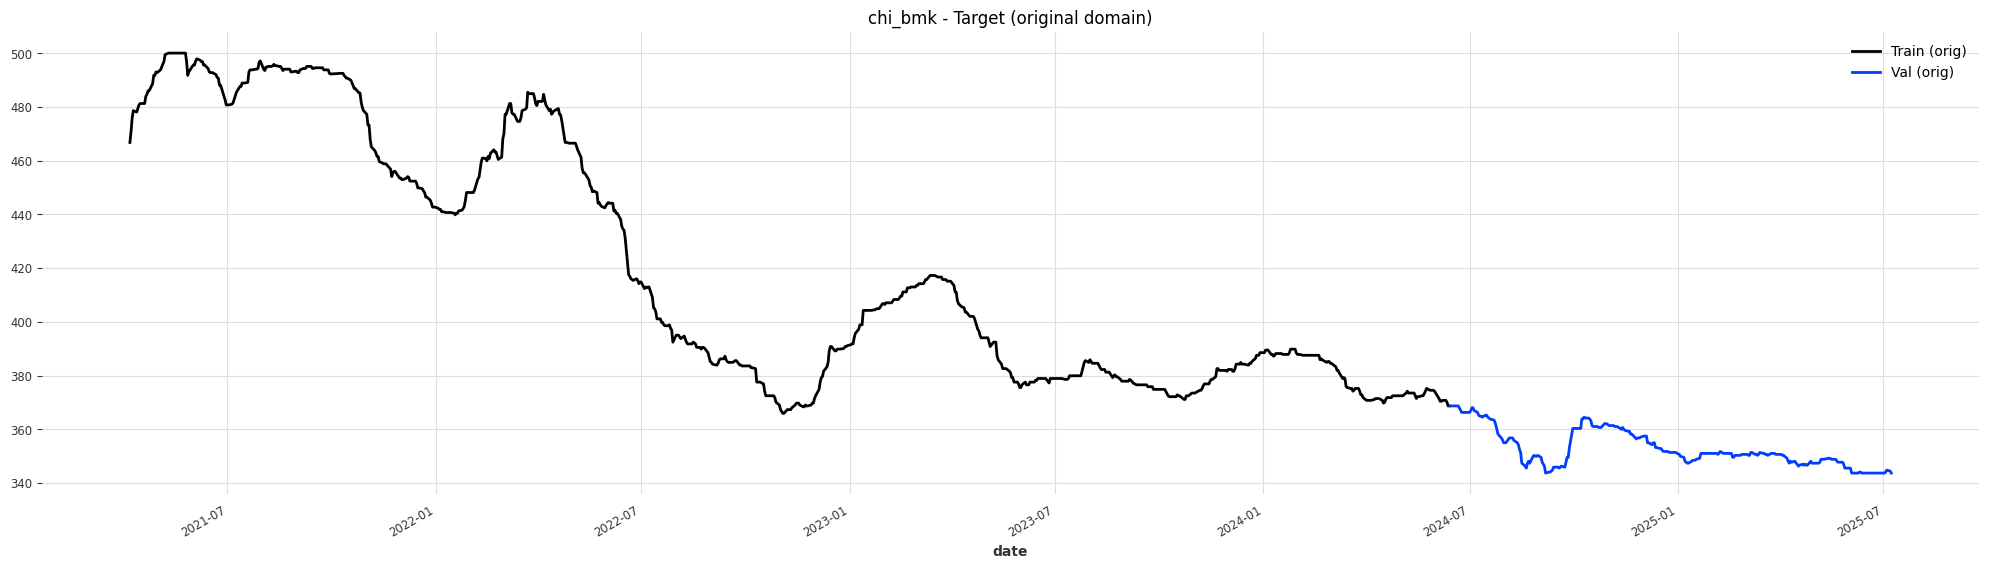

✅ Preprocess ready. Key variables:
- series_scaled_aligned: 1111 points
- train_scaled / val_scaled: 833 / 278
- covariates_all: 6 features, 1111 points
⚠️ Inside Optuna: recalculate covs_train/covs_val with the trial input_chunk_length.


In [3]:
# ============================================
# 🔧 PREPROCESS + COVARIATES
# ============================================

# -------------------------------
# 0) Transformation Helpers
# -------------------------------
TRANSFORM_CFG = {
    "kind": "log1p",  # "log" | "log1p" | "log_shift" | "none"
    "shift": 0.0,     # "log_shift"
}

def forward_transform(ts: TimeSeries) -> TimeSeries:
    k = TRANSFORM_CFG["kind"]; c = TRANSFORM_CFG["shift"]
    if k == "none":
        return ts
    if k == "log":
        return ts.map(np.log)              # values > 0
    if k == "log1p":
        return ts.map(np.log1p)            # zero tolerance
    if k == "log_shift":
        return ts.map(lambda v: np.log(v + c))  # choose c > -min(v)
    raise ValueError(f"Unknown transform kind: {k}")

def inverse_transform(ts: TimeSeries) -> TimeSeries:
    k = TRANSFORM_CFG["kind"]; c = TRANSFORM_CFG["shift"]
    if k == "none":
        return ts
    if k == "log":
        return ts.map(np.exp)
    if k == "log1p":
        return ts.map(np.expm1)
    if k == "log_shift":
        return ts.map(lambda v: np.exp(v) - c)
    raise ValueError(f"Unknown transform kind: {k}")

# --------------------------------------
# 1) Loading, cleaning and transformation
# --------------------------------------
TARGET_COL = "chi_bmk"

df = pd.read_excel("dataset/ds_benchmark.xlsx")
df["date"] = pd.to_datetime(df["date"])
df.set_index("date", inplace=True)
df = df.asfreq("B").reset_index().interpolate()

# Winsorization 1% (mitigates extreme outliers)
q01, q99 = df[TARGET_COL].quantile([0.01, 0.99])
df[TARGET_COL] = np.clip(df[TARGET_COL], q01, q99)

# Original series
series_raw = TimeSeries.from_dataframe(df, time_col="date", value_cols=TARGET_COL, freq="B")

# Transform + robust scale
series_trans   = forward_transform(series_raw)
scaler         = Scaler(scaler=RobustScaler())
series_scaled  = scaler.fit_transform(series_trans)

# -------------------------------------------------
# 2) Covariates: lags (1,5,22,66) + volatility
# -------------------------------------------------
def build_past_covariates(series_scaled: TimeSeries) -> TimeSeries:
    base_name = series_scaled.columns[0] if hasattr(series_scaled, "columns") else series_scaled.components[0]

    # Typical market lags
    lags = [1, 5, 22, 66]
    cov_list = []
    for l in lags:
        s = series_scaled.shift(l)
        s = s.with_columns_renamed([base_name], [f"lag_{l}"])
        cov_list.append(s)

    # Volatility (standard deviation) windows 5 and 22
    def rolling_std(ts: TimeSeries, w: int, name: str) -> TimeSeries:
        vals = pd.Series(ts.univariate_values()).rolling(window=w, min_periods=1).std().values
        return TimeSeries.from_times_and_values(ts.time_index, vals, columns=[name])

    vol5  = rolling_std(series_scaled, 5,  "vol5")
    vol22 = rolling_std(series_scaled, 22, "vol22")
    cov_list += [vol5, vol22]

    # Aligns all covariates to the same interval (avoids stack error)
    common_start = max(s.start_time() for s in cov_list)
    common_end   = min(s.end_time()   for s in cov_list)
    cov_list = [s.slice(common_start, common_end) for s in cov_list]

    covs = cov_list[0]
    for s in cov_list[1:]:
        covs = covs.stack(s)
    return covs

covariates_all = build_past_covariates(series_scaled)

# Aligns the target series to the range of covariates (ensures compatibility)
series_scaled_aligned = series_scaled.slice(covariates_all.start_time(), covariates_all.end_time())
series_trans_aligned  = series_trans.slice(covariates_all.start_time(), covariates_all.end_time())
series_raw_aligned    = inverse_transform(series_trans_aligned)

# -------------------------
# 3) Split (75% / 25%)
# -------------------------
train_size   = int(len(series_scaled_aligned) * 0.75)
train_scaled = series_scaled_aligned[:train_size]
val_scaled   = series_scaled_aligned[train_size:]

# For visual in original domain
train_trans = scaler.inverse_transform(train_scaled)
val_trans   = scaler.inverse_transform(val_scaled)
train_raw   = inverse_transform(train_trans)
val_raw     = inverse_transform(val_trans)

plt.figure(figsize=(25, 6))
train_raw.plot(label="Train (orig)")
val_raw.plot(label="Val (orig)")
plt.title(f"{TARGET_COL} - Target (original domain)")
plt.legend(); plt.show()

# --------------------------------------------
# 4) Covariate preparer (training/val)
#    -> recalculate with the trial input_chunk_length!
# --------------------------------------------
def prepare_covariates_flexible(
    covariates: TimeSeries,
    ref_series: TimeSeries,
    train_size: int,
    input_chunk_length: int,
    scaler_covs: Optional[Scaler] = None,
):
    val_ref    = ref_series[train_size:]
    covs_train = covariates[:train_size]

    start_needed = val_ref.start_time() - val_ref.freq * input_chunk_length
    # ensures that it does not ask before the start of the covariates
    start_needed = max(start_needed, covariates.start_time())

    covs_val = covariates.slice(start_needed, val_ref.end_time())

    # Robust scale also in covariates (consistent with the target)
    if scaler_covs is None:
        scaler_covs = Scaler(scaler=RobustScaler())
        covs_train  = scaler_covs.fit_transform(covs_train)
        covs_val    = scaler_covs.transform(covs_val)
    else:
        covs_train  = scaler_covs.transform(covs_train)
        covs_val    = scaler_covs.transform(covs_val)

    return covs_train, covs_val, scaler_covs

# Precompute with a default ICL (recompute within Optuna with the trial value!)
DEFAULT_ICL = 180
covs_train, covs_val, scaler_covs = prepare_covariates_flexible(
    covariates=covariates_all,
    ref_series=series_scaled_aligned,
    train_size=train_size,
    input_chunk_length=DEFAULT_ICL,
    scaler_covs=None,
)

# ----------------------------------------------------
# 5) Metrics helper in the ORIGINAL domain (optional)
#    -> use within Optuna and in "best run"
# ----------------------------------------------------
def metrics_on_original_domain(
    y_val_scaled: TimeSeries,
    y_pred: TimeSeries,
    y_train_scaled: Optional[TimeSeries],
    scaler_target: Scaler,
    reduce_to_median: bool = True,
):
    if reduce_to_median and getattr(y_pred, "is_stochastic", False):
        y_pred = y_pred.quantile_timeseries(0.5)

    # return from scaled -> transform
    y_val_trans  = scaler_target.inverse_transform(y_val_scaled)
    y_pred_trans = scaler_target.inverse_transform(y_pred)

    # return from transform -> original
    eps = 1e-12
    y_val_orig  = inverse_transform(y_val_trans).map(lambda v: np.maximum(v, eps))
    y_pred_orig = inverse_transform(y_pred_trans).map(lambda v: np.maximum(v, eps))

    out = {
        "mae":   mae(y_val_orig,  y_pred_orig),
        "mse":   mse(y_val_orig,  y_pred_orig),
        "rmse":  rmse(y_val_orig, y_pred_orig),
        "smape": smape(y_val_orig, y_pred_orig),
        "mape":  mape(y_val_orig, y_pred_orig),
        "marre": marre(y_val_orig, y_pred_orig),
    }

    if y_train_scaled is not None:
        y_train_trans = scaler_target.inverse_transform(y_train_scaled)
        y_train_orig  = inverse_transform(y_train_trans).map(lambda v: np.maximum(v, eps))
        out["mase"]   = mase(y_val_orig, y_pred_orig, y_train_orig)

    return out

print("✅ Preprocess ready. Key variables:")
print(f"- series_scaled_aligned: {len(series_scaled_aligned)} points")
print(f"- train_scaled / val_scaled: {len(train_scaled)} / {len(val_scaled)}")
print(f"- covariates_all: {covariates_all.width} features, {len(covariates_all)} points")
print("⚠️ Inside Optuna: recalculate covs_train/covs_val with the trial input_chunk_length.")

## Decomposition

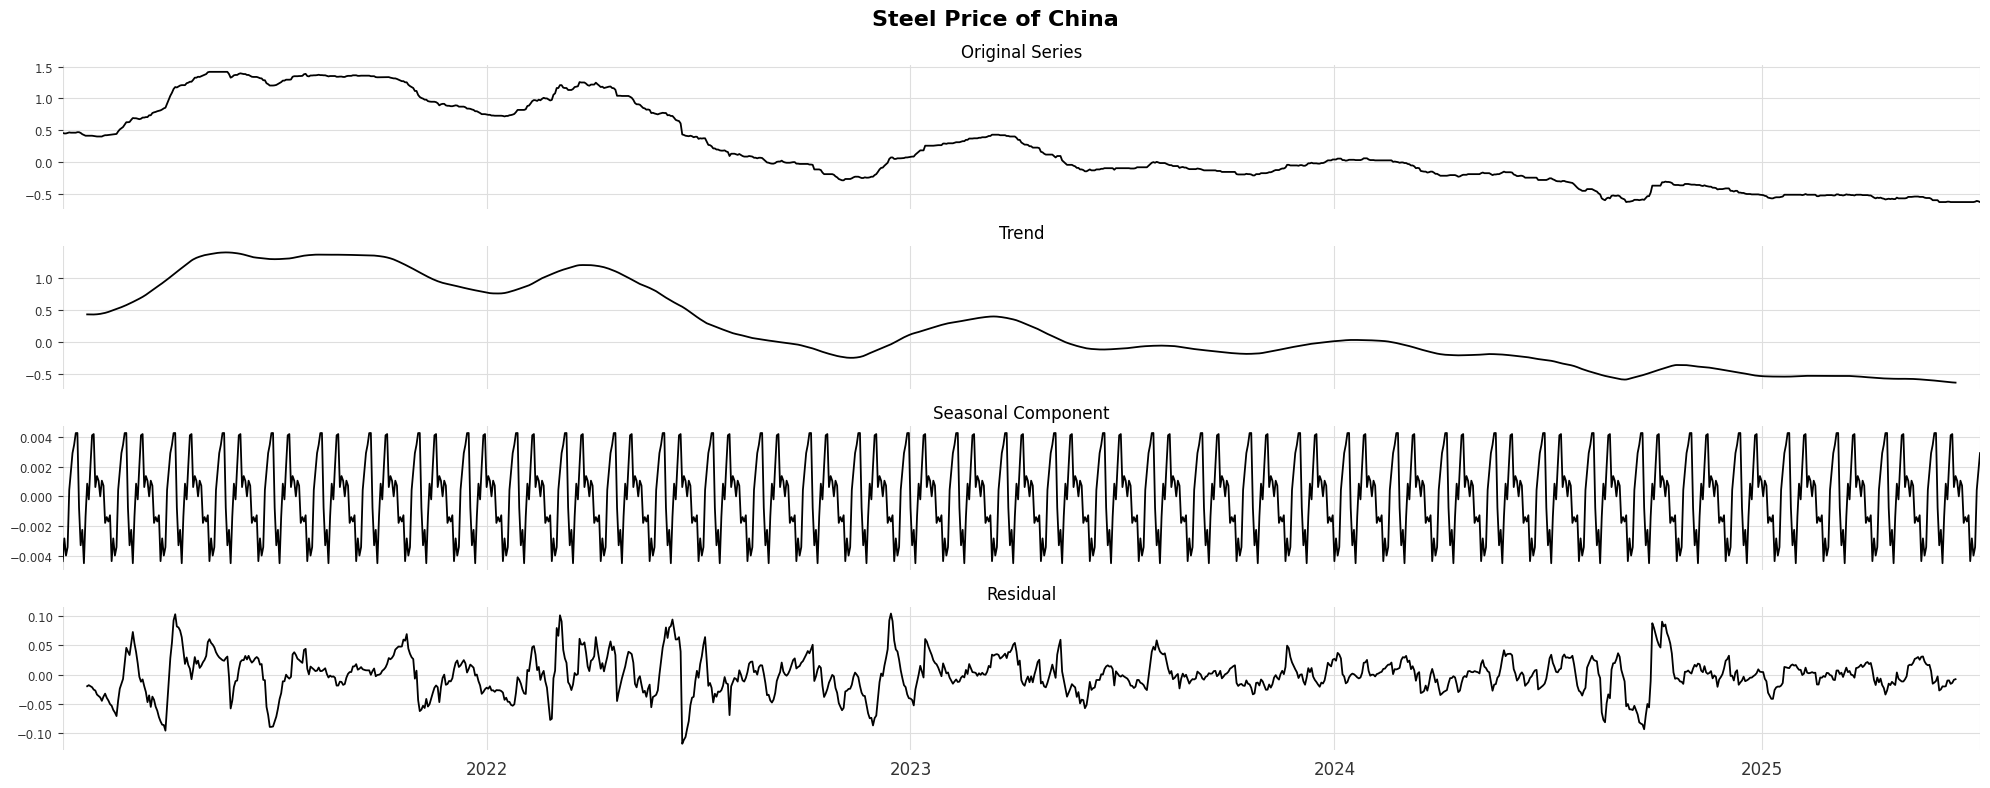

In [4]:
series_pd = series_scaled.values(copy=False).flatten()
index = series_scaled.time_index
series_pd = pd.Series(series_pd, index=index)

decomposition = seasonal_decompose(series_pd, model="additive", period=30)
fig, ax = plt.subplots(4, 1, figsize=(20, 8), sharex=True)
decomposition.observed.plot(ax=ax[0], title="Original Series")
decomposition.trend.plot(ax=ax[1], title="Trend")
decomposition.seasonal.plot(ax=ax[2], title="Seasonal Component")
decomposition.resid.plot(ax=ax[3], title="Residual")

for axis in ax:
    axis.tick_params(axis='x', labelsize=12)
ax[-1].set_xlabel("")
plt.suptitle("Steel Price of China", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Classic Models

## ARIMA

d:\dl_darts\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE(orig):  10.529386626254809
MSE(orig):  147.38101312915884
RMSE(orig): 12.140058201226172
RMSLE(orig): 0.034077935837607855
MAPE(orig): 3.018026036394262
SMAPE(orig): 2.9584470395031204
MASE(orig): 14.508994682892087
MARRE(orig): 42.09407068683328
Time: 0.6647
Updated: ARIMA
'error_chi' updated (aligned by date)!


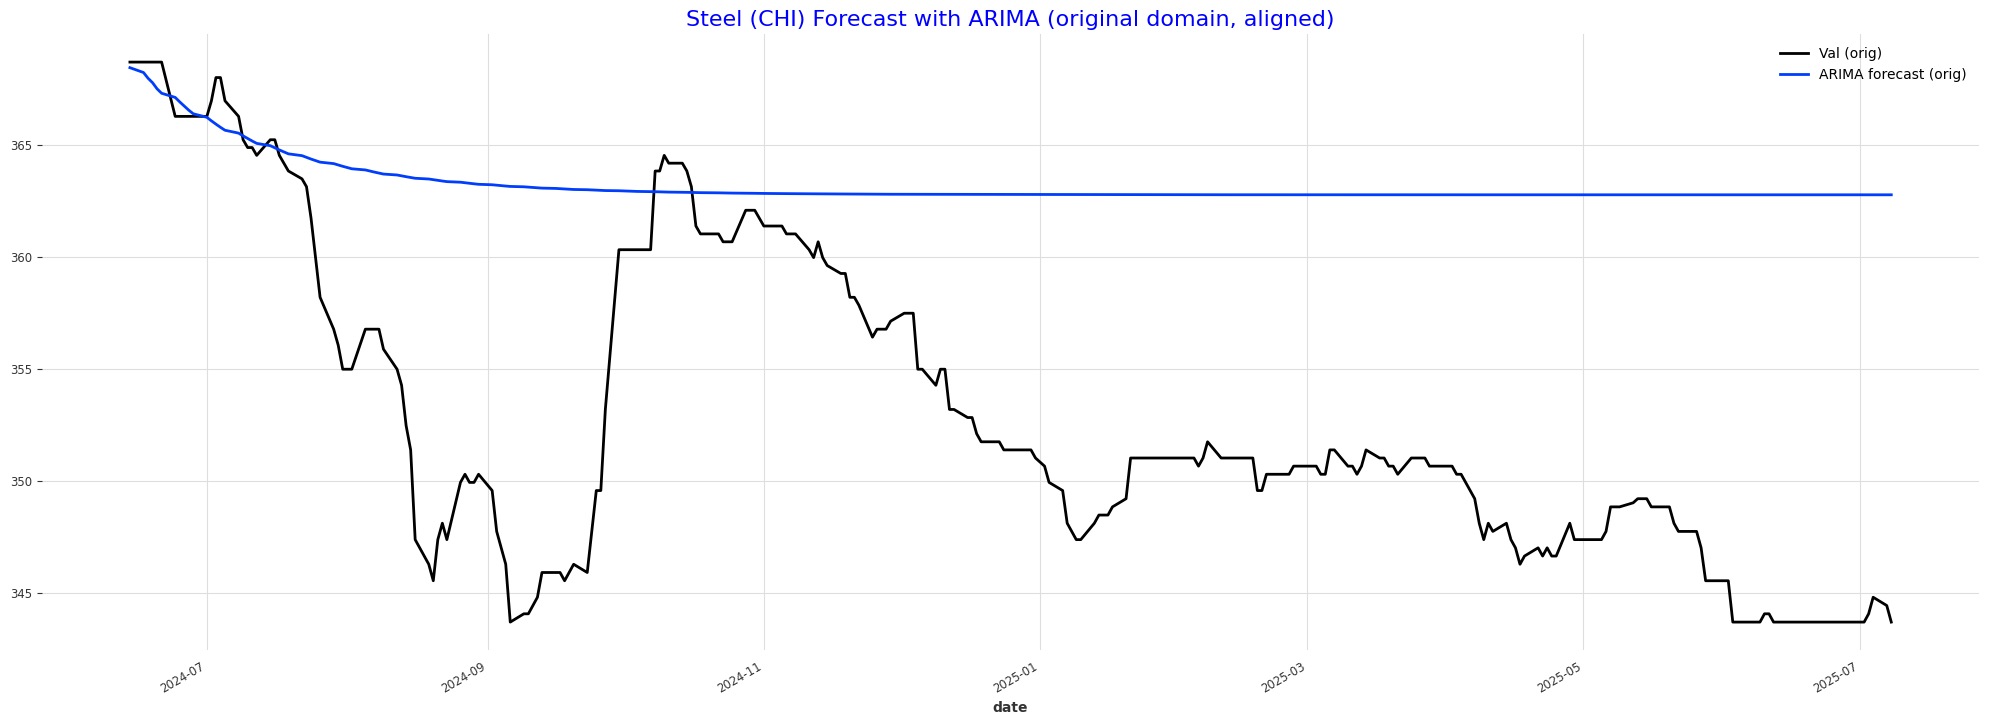

In [15]:
# ============================================
# 📈 ARIMA
# ============================================

start_time = time.time()

arima_model = ARIMA(p=5, d=1, q=5)
arima_model.fit(train_scaled)
arima_pred_scaled = arima_model.predict(n=len(val_scaled))

exec_time = round(time.time() - start_time, 4)

# ---------------------------
# Metrics
# ---------------------------
mets = metrics_on_original_domain(
    y_val_scaled=val_scaled,
    y_pred=arima_pred_scaled,
    y_train_scaled=train_scaled,
    scaler_target=scaler,
    reduce_to_median=True,
)

val_trans   = scaler.inverse_transform(val_scaled)
pred_trans  = scaler.inverse_transform(arima_pred_scaled)
val_orig    = inverse_transform(val_trans)
pred_orig   = inverse_transform(pred_trans)
rmsle_val   = rmsle(val_orig, pred_orig)

print(f"MAE(orig):  {mets['mae']}")
print(f"MSE(orig):  {mets['mse']}")
print(f"RMSE(orig): {mets['rmse']}")
print(f"RMSLE(orig): {rmsle_val}")
print(f"MAPE(orig): {mets['mape']}")
print(f"SMAPE(orig): {mets['smape']}")
print(f"MASE(orig): {mets.get('mase', np.nan)}")
print(f"MARRE(orig): {mets['marre']}")
print(f"Time: {exec_time}")

# ============================================
# 🗂️ Summary (CHI)
# ============================================
result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
sheet_name_summary = "summary_chi"

new_row = {
    'Dataset': 'Steel (CHI)',
    'Model': 'ARIMA',
    'MAE': mets['mae'],
    'MSE': mets['mse'],
    'RMSE': mets['rmse'],
    'RMSLE': rmsle_val,
    'MAPE': mets['mape'],
    'SMAPE': mets['smape'],
    'MASE': mets.get('mase', np.nan),
    'MARRE': mets['marre'],
    'Time': exec_time
}

required_cols = list(new_row.keys())

def ensure_schema(df, required_cols):
    """Garante que df tenha exatamente as colunas esperadas (cria se faltar)."""
    if df is None or df.empty:
        return pd.DataFrame(columns=required_cols)
    for c in required_cols:
        if c not in df.columns:
            df[c] = np.nan
    return df[required_cols]

try:
    summary_df = pd.read_excel(excel_file_path, sheet_name=sheet_name_summary)
    summary_df = ensure_schema(summary_df, required_cols)
    if not set(['Dataset','Model']).issubset(summary_df.columns):
        summary_df = pd.DataFrame(columns=required_cols)

    mask = (summary_df['Dataset'] == new_row['Dataset']) & (summary_df['Model'] == new_row['Model'])
    if mask.any():
        summary_df.loc[mask, required_cols[2:]] = [new_row[k] for k in required_cols[2:]]
        print("Updated: ARIMA")
    else:
        summary_df = pd.concat([summary_df, pd.DataFrame([new_row])], ignore_index=True)
        print("Add new model: ARIMA")

except (FileNotFoundError, ValueError):
    summary_df = pd.DataFrame([new_row], columns=required_cols)
    print("Created new Summary (sheet/file).")

with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name_summary, index=False)


# ============================================
# 🧾 Errors DF
# ============================================
eps = 1e-12

# Use only the common range between prediction and validation (ORIGINAL domain)
common_start = max(val_orig.start_time(), pred_orig.start_time())
common_end   = min(val_orig.end_time(),   pred_orig.end_time())
val_common   = val_orig.slice(common_start, common_end)
pred_common  = pred_orig.slice(common_start, common_end)

# Aligned arrays
y_true = val_common.univariate_values()
y_hat  = pred_common.univariate_values()
dates  = val_common.time_index

# New dataframe for this model
df_new = pd.DataFrame({
    "date": dates,
    "arima_pred":  y_hat,
    "arima_error": np.abs(y_hat - y_true),
    "arima_smape": 100 * (2.0 * np.abs(y_true - y_hat) /
                          (np.abs(y_true) + np.abs(y_hat) + eps))
})

excel_file_path = "result/dlr_result_chi.xlsx"
sheet_name_err = "error_chi"

try:
    old = pd.read_excel(excel_file_path, sheet_name=sheet_name_err)
    if "date" in old.columns:
        old["date"] = pd.to_datetime(old["date"])
    else:
        old = pd.DataFrame({"date": df_new["date"]})
    merged = pd.merge(old, df_new, on="date", how="outer")
    merged.sort_values("date", inplace=True)
except (ValueError, FileNotFoundError):
    merged = df_new

with pd.ExcelWriter(excel_file_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    merged.to_excel(writer, sheet_name=sheet_name_err, index=False)

print(f"'{sheet_name_err}' updated (aligned by date)!")

# ============================================
# 📉 Plot
# ============================================
plt.figure(figsize=(25, 8))
val_common.plot(label="Val (orig)")
pred_common.plot(label="ARIMA forecast (orig)")
plt.title("Steel (CHI) Forecast with ARIMA (original domain, aligned)", fontsize=16, color='blue')
plt.legend()
plt.grid(True)
plt.show()

## Exponential Smoothing

MAE(orig):  29.455252361152123
MSE(orig):  1254.7133934056747
RMSE(orig): 35.42193378975342
RMSLE(orig): 0.10879544379926821
MAPE(orig): 8.411908921545589
SMAPE(orig): 8.964128808985052
MASE(orig): 40.58793879080972
MARRE(orig): 117.75533741891537
Time: 0.1689
Updated: Exponential Smoothing
'error_chi' updated (aligned by date)!


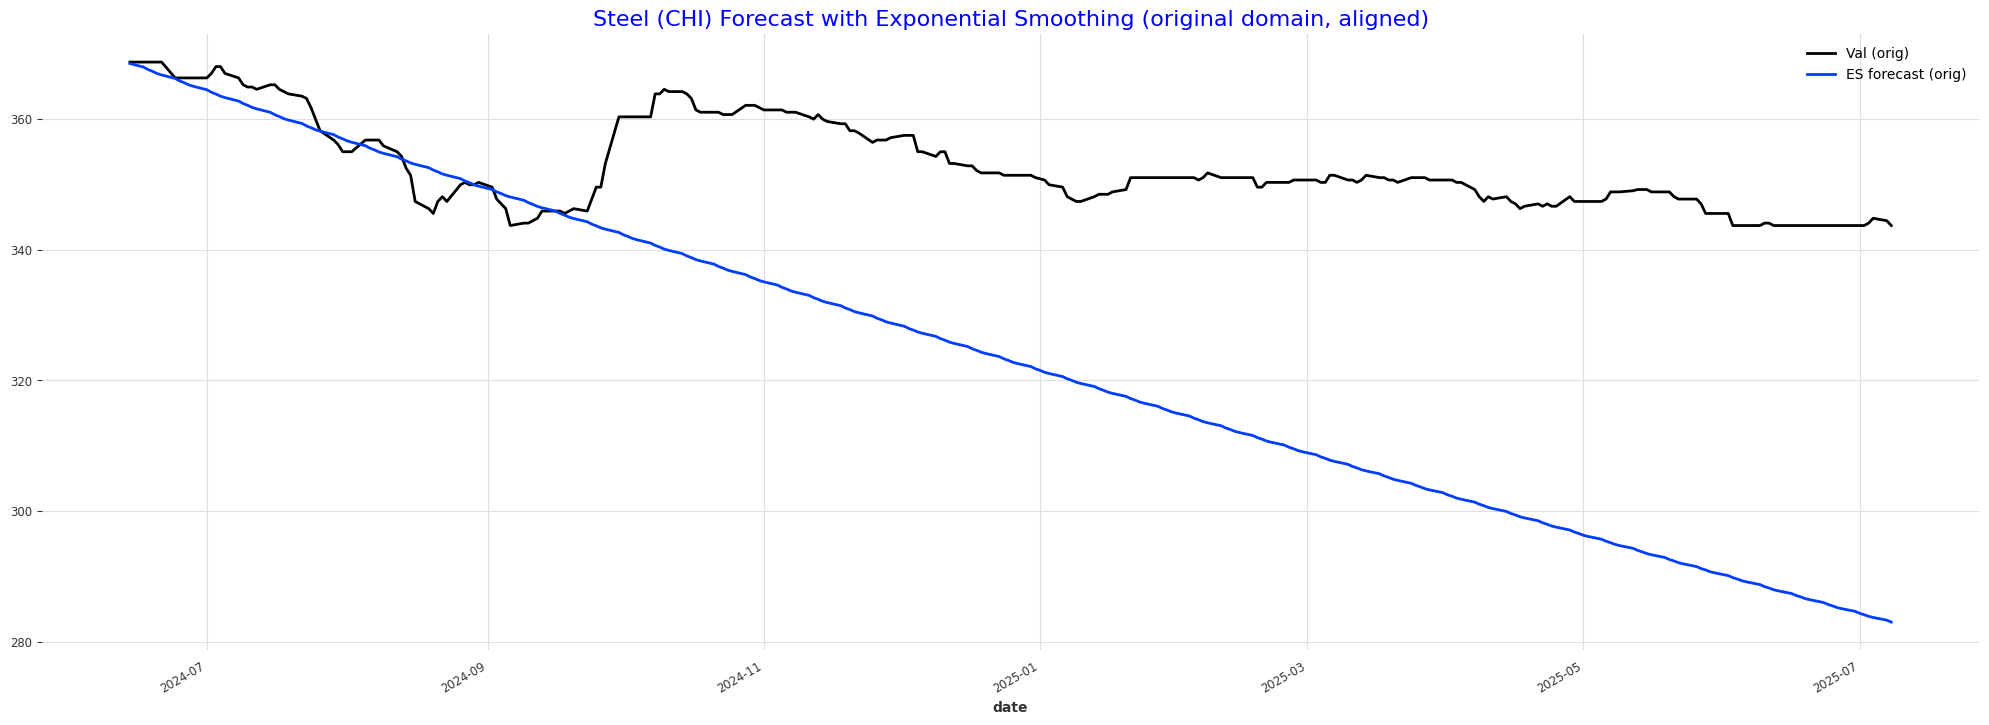

In [16]:
# ============================================
# 📈 Exponential Smoothing
# ============================================

start_time = time.time()

es_model = ExponentialSmoothing()
es_model.fit(train_scaled)
es_pred_scaled = es_model.predict(n=len(val_scaled))

exec_time = round(time.time() - start_time, 4)

# ---------------------------
# Metrics
# ---------------------------
mets = metrics_on_original_domain(
    y_val_scaled=val_scaled,
    y_pred=es_pred_scaled,
    y_train_scaled=train_scaled,
    scaler_target=scaler,
    reduce_to_median=True,
)

val_trans  = scaler.inverse_transform(val_scaled)
pred_trans = scaler.inverse_transform(es_pred_scaled)
val_orig   = inverse_transform(val_trans)
pred_orig  = inverse_transform(pred_trans)
rmsle_val  = rmsle(val_orig, pred_orig)

print(f"MAE(orig):  {mets['mae']}")
print(f"MSE(orig):  {mets['mse']}")
print(f"RMSE(orig): {mets['rmse']}")
print(f"RMSLE(orig): {rmsle_val}")
print(f"MAPE(orig): {mets['mape']}")
print(f"SMAPE(orig): {mets['smape']}")
print(f"MASE(orig): {mets.get('mase', np.nan)}")
print(f"MARRE(orig): {mets['marre']}")
print(f"Time: {exec_time}")

# ============================================
# 🗂️ Summary (CHI)
# ============================================
result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
sheet_name_summary = "summary_chi"

new_row = {
    'Dataset': 'Steel (CHI)',
    'Model': 'Exponential Smoothing',
    'MAE': mets['mae'],
    'MSE': mets['mse'],
    'RMSE': mets['rmse'],
    'RMSLE': rmsle_val,
    'MAPE': mets['mape'],
    'SMAPE': mets['smape'],
    'MASE': mets.get('mase', np.nan),
    'MARRE': mets['marre'],
    'Time': exec_time
}

required_cols = list(new_row.keys())

def ensure_schema(df, required_cols):
    """Garante que df tenha as colunas esperadas; cria faltantes e reordena."""
    if df is None or df.empty:
        return pd.DataFrame(columns=required_cols)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    for c in required_cols:
        if c not in df.columns:
            df[c] = np.nan
    return df[required_cols]

try:
    summary_df = pd.read_excel(excel_file_path, sheet_name=sheet_name_summary)
    summary_df = ensure_schema(summary_df, required_cols)

    # upsert por (Dataset, Model)
    mask = (summary_df['Dataset'] == new_row['Dataset']) & (summary_df['Model'] == new_row['Model'])
    if mask.any():
        summary_df.loc[mask, required_cols[2:]] = [new_row[k] for k in required_cols[2:]]
        print("Updated: Exponential Smoothing")
    else:
        summary_df = pd.concat([summary_df, pd.DataFrame([new_row])], ignore_index=True)
        print("Add new model: Exponential Smoothing")

except (FileNotFoundError, ValueError):
    summary_df = pd.DataFrame([new_row], columns=required_cols)
    print("Created new Summary (sheet/file).")

with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name_summary, index=False)


# ============================================
# 🧾 Errors DF
# ============================================
eps = 1e-12

common_start = max(val_orig.start_time(), pred_orig.start_time())
common_end   = min(val_orig.end_time(),   pred_orig.end_time())
val_common   = val_orig.slice(common_start, common_end)
pred_common  = pred_orig.slice(common_start, common_end)

# Aligned arrays
y_true = val_common.univariate_values()
y_hat  = pred_common.univariate_values()
dates  = val_common.time_index

# New dataframe for this model
df_new = pd.DataFrame({
    "date": dates,
    "es_pred":  y_hat,
    "es_error": np.abs(y_hat - y_true),
    "es_smape": 100 * (2.0 * np.abs(y_true - y_hat) /
                       (np.abs(y_true) + np.abs(y_hat) + eps))
})

sheet_name_err = "error_chi"

try:
    old = pd.read_excel(excel_file_path, sheet_name=sheet_name_err)
    if "date" in old.columns:
        old["date"] = pd.to_datetime(old["date"])
    else:
        old = pd.DataFrame({"date": df_new["date"]})
    merged = pd.merge(old, df_new, on="date", how="outer")
    merged.sort_values("date", inplace=True)
except (ValueError, FileNotFoundError):
    merged = df_new

with pd.ExcelWriter(excel_file_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    merged.to_excel(writer, sheet_name=sheet_name_err, index=False)

print(f"'{sheet_name_err}' updated (aligned by date)!")

# ============================================
# 📉 Plot
# ============================================
plt.figure(figsize=(25, 8))
val_common.plot(label="Val (orig)")
pred_common.plot(label="ES forecast (orig)")
plt.title("Steel (CHI) Forecast with Exponential Smoothing (original domain, aligned)", fontsize=16, color='blue')
plt.legend()
plt.grid(True)
plt.show()

## Linear Regression

MAE(orig):  18.211216545677065
MSE(orig):  383.8352581336352
RMSE(orig): 19.591714017248087
RMSLE(orig): 0.054192049453634865
MAPE(orig): 5.196672027432756
SMAPE(orig): 5.044476668507551
MASE(orig): 25.094191467087146
MARRE(orig): 72.80426332294572
Time: 0.0173
Updated: Linear Regression
'error_chi' updated (aligned by date)!


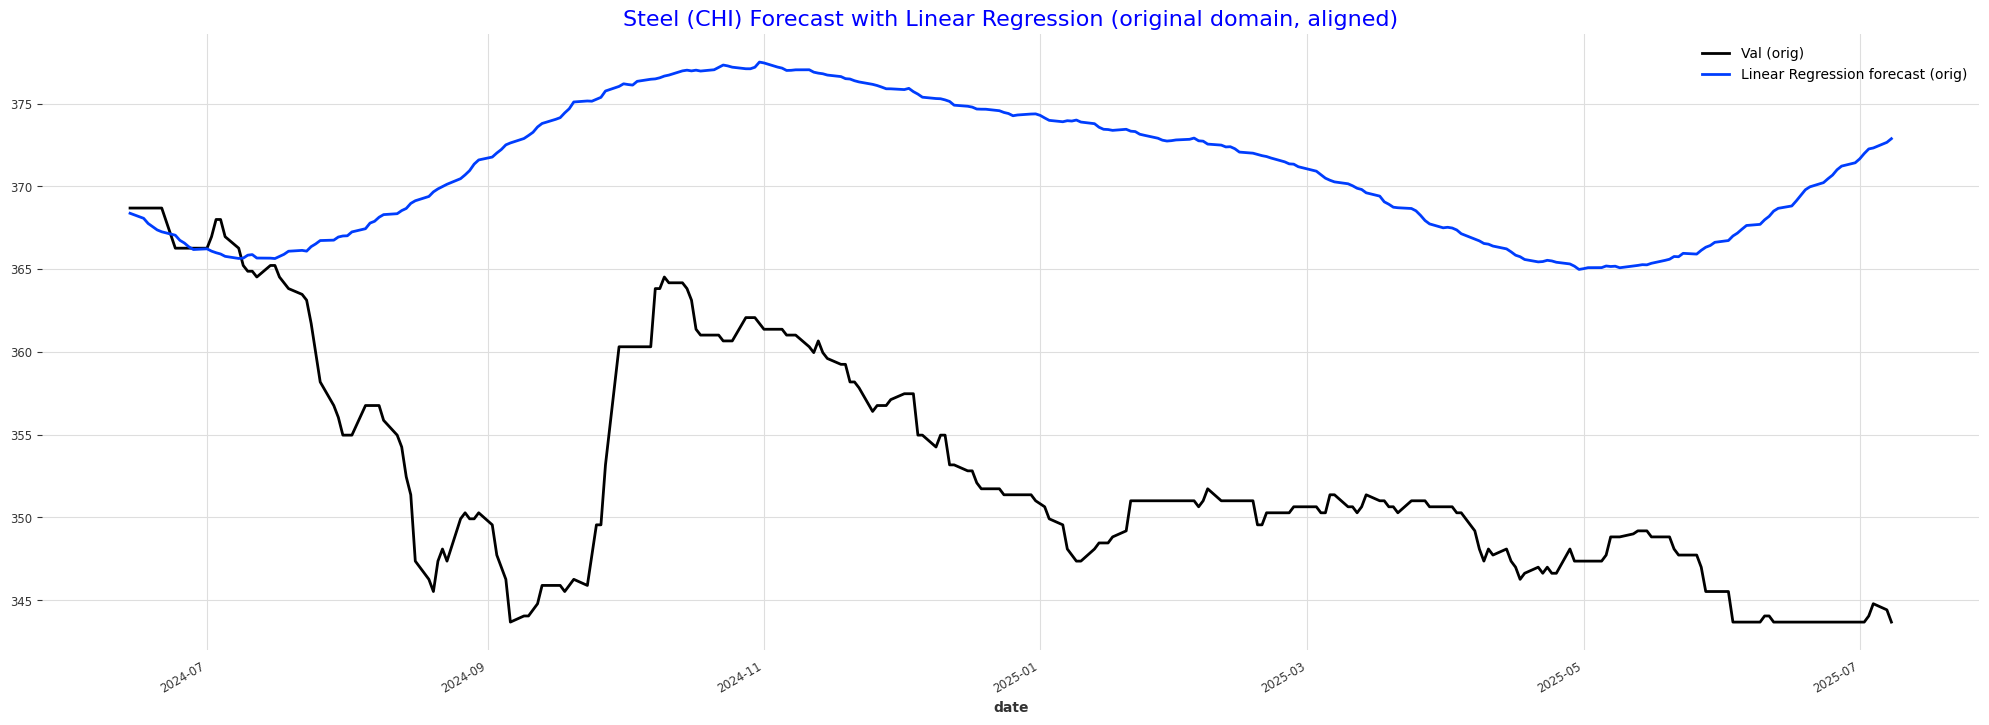

In [17]:
# ============================================
# 📈 Linear Regression
# ============================================

start_time = time.time()

lr_model = LinearRegressionModel(
    lags=12,
    output_chunk_length=len(val_scaled),
)

lr_model.fit(train_scaled)
lr_pred_scaled = lr_model.predict(n=len(val_scaled))

exec_time = round(time.time() - start_time, 4)

# ---------------------------
# Metrics
# ---------------------------
mets = metrics_on_original_domain(
    y_val_scaled=val_scaled,
    y_pred=lr_pred_scaled,
    y_train_scaled=train_scaled,
    scaler_target=scaler,
    reduce_to_median=True,
)

val_trans  = scaler.inverse_transform(val_scaled)
pred_trans = scaler.inverse_transform(lr_pred_scaled)
val_orig   = inverse_transform(val_trans)
pred_orig  = inverse_transform(pred_trans)
rmsle_val  = rmsle(val_orig, pred_orig)

print(f"MAE(orig):  {mets['mae']}")
print(f"MSE(orig):  {mets['mse']}")
print(f"RMSE(orig): {mets['rmse']}")
print(f"RMSLE(orig): {rmsle_val}")
print(f"MAPE(orig): {mets['mape']}")
print(f"SMAPE(orig): {mets['smape']}")
print(f"MASE(orig): {mets.get('mase', np.nan)}")
print(f"MARRE(orig): {mets['marre']}")
print(f"Time: {exec_time}")

# ============================================
# 🗂️ Summary (CHI)
# ============================================
result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
sheet_name_summary = "summary_chi"

new_row = {
    'Dataset': 'Steel (CHI)',
    'Model': 'Linear Regression',
    'MAE': mets['mae'],
    'MSE': mets['mse'],
    'RMSE': mets['rmse'],
    'RMSLE': rmsle_val,
    'MAPE': mets['mape'],
    'SMAPE': mets['smape'],
    'MASE': mets.get('mase', np.nan),
    'MARRE': mets['marre'],
    'Time': exec_time
}

required_cols = list(new_row.keys())

def ensure_schema(df, required_cols):
    """Garante colunas esperadas; remove 'Unnamed:*'; cria faltantes e reordena."""
    if df is None or df.empty:
        return pd.DataFrame(columns=required_cols)
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
    for c in required_cols:
        if c not in df.columns:
            df[c] = np.nan
    return df[required_cols]

try:
    summary_df = pd.read_excel(excel_file_path, sheet_name=sheet_name_summary)
    summary_df = ensure_schema(summary_df, required_cols)

    # Upsert por (Dataset, Model)
    mask = (summary_df['Dataset'] == new_row['Dataset']) & (summary_df['Model'] == new_row['Model'])
    if mask.any():
        summary_df.loc[mask, required_cols[2:]] = [new_row[k] for k in required_cols[2:]]
        print("Updated: Linear Regression")
    else:
        summary_df = pd.concat([summary_df, pd.DataFrame([new_row])], ignore_index=True)
        print("Add new model: Linear Regression")

except (FileNotFoundError, ValueError):
    summary_df = pd.DataFrame([new_row], columns=required_cols)
    print("Created new Summary (sheet/file).")

with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name_summary, index=False)


# ============================================
# 🧾 Errors DF
# ============================================
eps = 1e-12

common_start = max(val_orig.start_time(), pred_orig.start_time())
common_end   = min(val_orig.end_time(),   pred_orig.end_time())
val_common   = val_orig.slice(common_start, common_end)
pred_common  = pred_orig.slice(common_start, common_end)

# Aligned arrays
y_true = val_common.univariate_values()
y_hat  = pred_common.univariate_values()
dates  = val_common.time_index

# New dataframe for LR
df_new = pd.DataFrame({
    "date": dates,
    "lr_pred":  y_hat,
    "lr_error": np.abs(y_hat - y_true),
    "lr_smape": 100 * (2.0 * np.abs(y_true - y_hat) /
                       (np.abs(y_true) + np.abs(y_hat) + eps))
})

sheet_name_err = "error_chi"

try:
    old = pd.read_excel(excel_file_path, sheet_name=sheet_name_err)
    if "date" in old.columns:
        old["date"] = pd.to_datetime(old["date"])
    else:
        old = pd.DataFrame({"date": df_new["date"]})
    merged = pd.merge(old, df_new, on="date", how="outer")
    merged.sort_values("date", inplace=True)
except (ValueError, FileNotFoundError):
    merged = df_new

with pd.ExcelWriter(excel_file_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    merged.to_excel(writer, sheet_name=sheet_name_err, index=False)

print(f"'{sheet_name_err}' updated (aligned by date)!")

# ============================================
# 📉 Plot
# ============================================
plt.figure(figsize=(25, 8))
val_common.plot(label="Val (orig)")
pred_common.plot(label="Linear Regression forecast (orig)")
plt.title("Steel (CHI) Forecast with Linear Regression (original domain, aligned)", fontsize=16, color='blue')
plt.legend()
plt.grid(True)
plt.show()


# Deep Learning Models

## Recurrent Neural Networks (RNN)

In [5]:
# ============================================
# RNN (LSTM/GRU/RNN)
# ============================================

# ---------------------------
# 0) FUTURE covariates
# ---------------------------
def build_future_time_covariates(ref_series: TimeSeries) -> TimeSeries:
    """
    Creates deterministic covariates known in the future:
        - linear trend
        - seasonal (approx. 5, 21, and ~252 business days)
    """
    idx = ref_series.time_index
    n = len(idx)
    t = np.arange(n)

    trend = TimeSeries.from_times_and_values(idx, (t - t.min()) / max(1, (t.max()-t.min())), columns=["trend"])

    def sincos(period, prefix):
        ang = 2 * np.pi * t / period
        sinv = TimeSeries.from_times_and_values(idx, np.sin(ang), columns=[f"{prefix}_sin"])
        cosv = TimeSeries.from_times_and_values(idx, np.cos(ang), columns=[f"{prefix}_cos"])
        return sinv, cosv

    w_sin, w_cos   = sincos(5,   "p5")    # ~semana útil
    m_sin, m_cos   = sincos(21,  "p21")   # ~mês útil
    y_sin, y_cos   = sincos(252, "p252")  # ~ano útil

    covs = trend.stack(w_sin).stack(w_cos).stack(m_sin).stack(m_cos).stack(y_sin).stack(y_cos)
    return covs

# create and scale future covariates
future_covs_all = build_future_time_covariates(series_scaled_aligned)
scaler_future_covs = Scaler(scaler=RobustScaler())
future_covs_all = scaler_future_covs.fit_transform(future_covs_all)

def prepare_future_covariates_flexible(
    covariates: TimeSeries,
    ref_series: TimeSeries,
    train_size: int,
    input_chunk_length: int,
):
    """
    For RNN with future_covariates:
        - covs_train: same training dates
        - covs_pred: covers [val.start - ICL, val.end] to ensure context
    """
    val_ref = ref_series[train_size:]
    covs_train = covariates[:train_size]

    start_needed = val_ref.start_time() - val_ref.freq * input_chunk_length
    start_needed = max(start_needed, covariates.start_time())
    covs_pred = covariates.slice(start_needed, val_ref.end_time())
    return covs_train, covs_pred

# ---------------------------------
# Optuna
# ---------------------------------
optuna_results = []
lr_scheduler = ReduceLROnPlateau

def objective(trial):
    # ---------------------------
    # Hyperparameters
    # ---------------------------
    model_type = trial.suggest_categorical("model", ["LSTM", "GRU", "RNN"])
    input_chunk_length = trial.suggest_int("input_chunk_length", 32, 96, step=32)

    if len(val_scaled) < input_chunk_length:
        raise optuna.exceptions.TrialPruned()
        
    training_length = trial.suggest_int("training_length", input_chunk_length + 24, input_chunk_length + 120, step=12)
    hidden_dim = trial.suggest_categorical("hidden_dim", [32, 64, 128])
    n_rnn_layers = trial.suggest_int("n_rnn_layers", 1, 4)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-4, log=True)
    loss_name = trial.suggest_categorical("loss_fn", ["mse", "huber"])
    loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
    use_likelihood = trial.suggest_categorical("use_likelihood", [True, False])
    likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None

    # --- CALLBACK DE EARLY STOPPING ---
    stopper = EarlyStopping(
        monitor="val_loss", patience=25, min_delta=0.001, verbose=False, mode='min'
    )
    
    covs_train_fut, covs_pred_fut = prepare_future_covariates_flexible(
        covariates=future_covs_all, ref_series=series_scaled_aligned, train_size=train_size,
        input_chunk_length=input_chunk_length,
    )

    # ---------------------------
    # Model
    # ---------------------------
    final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
    final_pl_kwargs["callbacks"] = [stopper]

    other_torch_kwargs = torch_kwargs.copy()
    other_torch_kwargs.pop("pl_trainer_kwargs", None)

    model = RNNModel(
        model=model_type,
        input_chunk_length=input_chunk_length,
        training_length=training_length,
        hidden_dim=hidden_dim,
        n_rnn_layers=n_rnn_layers,
        dropout=dropout,
        batch_size=64,
        n_epochs=500,  
        likelihood=likelihood,
        optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
        random_state=42,
        force_reset=True,
        save_checkpoints=True,
        loss_fn=loss_fn, 
        lr_scheduler_cls=lr_scheduler,
        lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False},
        pl_trainer_kwargs=final_pl_kwargs,
        **other_torch_kwargs
    )

    try:
        start_time = time.time()

        model.fit(
            series=train_scaled,
            future_covariates=covs_train_fut,
            val_series=val_scaled,
            val_future_covariates=covs_pred_fut,
            verbose=False
        )

        prediction = model.predict(
            n=len(val_scaled),
            future_covariates=covs_pred_fut,
            num_samples=300 if use_likelihood else 1
        )

        exec_time = round(time.time() - start_time, 4)

        mets = metrics_on_original_domain(
            y_val_scaled=val_scaled, y_pred=prediction, y_train_scaled=train_scaled,
            scaler_target=scaler, reduce_to_median=True,
        )
        pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
        val_trans = scaler.inverse_transform(val_scaled)
        pred_trans = scaler.inverse_transform(pred_point)
        val_orig = inverse_transform(val_trans)
        pred_orig = inverse_transform(pred_trans)
        rmsle_val = rmsle(val_orig, pred_orig)
        
        optuna_results.append({
            "trial": trial.number, 
            "model": model_type, 
            "input_chunk_length": input_chunk_length,
            "training_length": training_length, 
            "hidden_dim": hidden_dim,
            "n_rnn_layers": n_rnn_layers, 
            "dropout": dropout, 
            "lr": lr, 
            "weight_decay": weight_decay,
            "loss_fn": loss_name, 
            "use_likelihood": use_likelihood,
            "mae": mets["mae"], 
            "mse": mets["mse"], 
            "rmse": mets["rmse"],
            "rmsle": rmsle_val, 
            "mape": mets["mape"], 
            "smape": mets["smape"],
            "mase": mets.get("mase", np.nan), 
            "marre": mets["marre"], 
            "time": exec_time
        })
        print(f"Trial {trial.number} [{model_type}] | sMAPE(orig): {mets['smape']:.4f} | t={exec_time}s")
        return mets["smape"]

    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return float("inf")

# ============================
# Run Optuna
# ============================
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

rnn_opt = pd.DataFrame(optuna_results).sort_values(by="smape").reset_index(drop=True)

# Save Results
result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')

if os.path.exists(excel_file_path):
    try:
        with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            rnn_opt.to_excel(writer, sheet_name='rnn_opt', index=False)
    except Exception as e:
        print(f"Error adding the sheet 'rnn_opt': {e}")
else:
    with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='w') as writer:
        rnn_opt.to_excel(writer, sheet_name='rnn_opt', index=False)

Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 0 [GRU] | sMAPE(orig): 6.1567 | t=71.3791s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 1 [GRU] | sMAPE(orig): 6.0635 | t=13.5503s


Predicting: |          | 0/? [00:00<?, ?it/s]

...

Trial 47 [LSTM] | sMAPE(orig): 4.5204 | t=42.1443s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 48 [RNN] | sMAPE(orig): 3.3758 | t=13.8136s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 49 [RNN] | sMAPE(orig): 5.0601 | t=23.7364s


Training the best model RNN (RNN)...
Predicting...


Predicting: |          | 0/? [00:00<?, ?it/s]


Best Model Metrics RNN (RNN):
MAE(orig):   6.0301
MSE(orig):   52.6115
RMSE(orig):  7.2534
RMSLE(orig): 0.0204
MAPE(orig):  1.7103%
SMAPE(orig): 1.7025%
Time:        10.2742s
Updated: RNN
'error_chi' updated (aligned by date)!


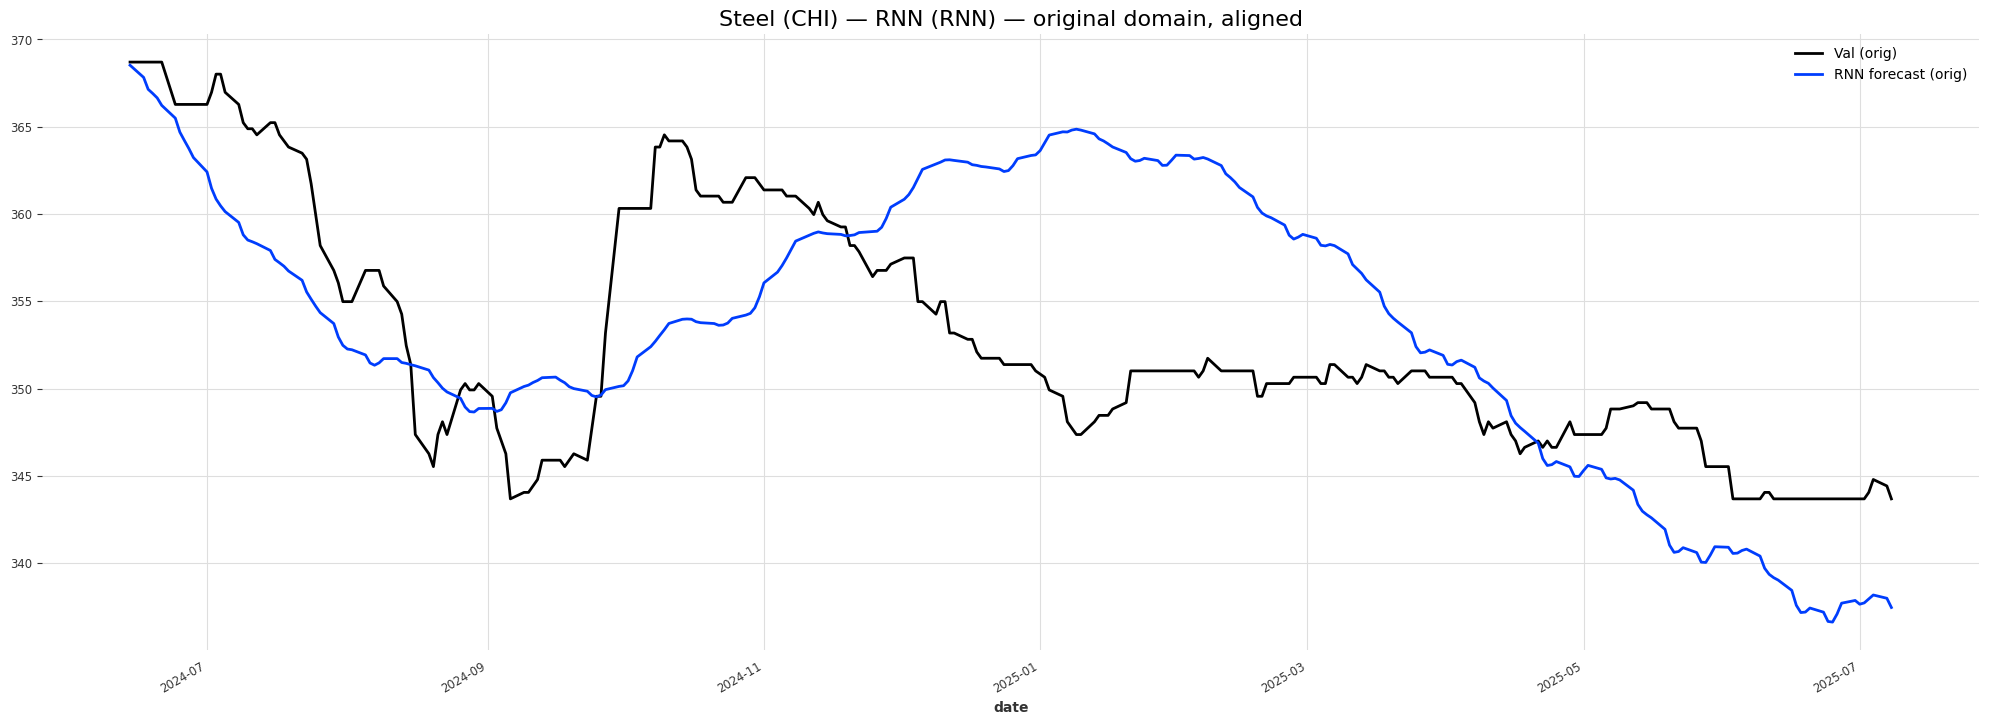

In [6]:
# ============================================
# Best run RNN
# ============================================

result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
rnn_opt_df = pd.read_excel(excel_file_path, sheet_name='rnn_opt')
best = rnn_opt_df.iloc[0]

# ---------------------------
# FUTURE covariates
# ---------------------------
def build_future_time_covariates(ref_series: TimeSeries) -> TimeSeries:
    """
    Creates deterministic covariates known in the future:
        - linear trend
        - seasonal (approx. 5, 21, and ~252 business days)
    """
    idx = ref_series.time_index
    n = len(idx)
    t = np.arange(n)

    trend = TimeSeries.from_times_and_values(idx, (t - t.min()) / max(1, (t.max()-t.min())), columns=["trend"])

    def sincos(period, prefix):
        ang = 2 * np.pi * t / period
        sinv = TimeSeries.from_times_and_values(idx, np.sin(ang), columns=[f"{prefix}_sin"])
        cosv = TimeSeries.from_times_and_values(idx, np.cos(ang), columns=[f"{prefix}_cos"])
        return sinv, cosv

    w_sin, w_cos   = sincos(5,   "p5")    # ~semana útil
    m_sin, m_cos   = sincos(21,  "p21")   # ~mês útil
    y_sin, y_cos   = sincos(252, "p252")  # ~ano útil

    covs = trend.stack(w_sin).stack(w_cos).stack(m_sin).stack(m_cos).stack(y_sin).stack(y_cos)
    return covs

# create and scale future covariates
future_covs_all = build_future_time_covariates(series_scaled_aligned)
scaler_future_covs = Scaler(scaler=RobustScaler())
future_covs_all = scaler_future_covs.fit_transform(future_covs_all)

def prepare_future_covariates_flexible(
    covariates: TimeSeries,
    ref_series: TimeSeries,
    train_size: int,
    input_chunk_length: int,
):
    """
    For RNN with future_covariates:
        - covs_train: same training dates
        - covs_pred: covers [val.start - ICL, val.end] to ensure context
    """
    val_ref = ref_series[train_size:]
    covs_train = covariates[:train_size]

    start_needed = val_ref.start_time() - val_ref.freq * input_chunk_length
    start_needed = max(start_needed, covariates.start_time())
    covs_pred = covariates.slice(start_needed, val_ref.end_time())
    return covs_train, covs_pred

# ---------------------------
# Hyperparamers
# ---------------------------

model_type = str(best["model"])
input_chunk_length = int(best["input_chunk_length"])
training_length = int(best["training_length"])
hidden_dim = int(best["hidden_dim"])
n_rnn_layers = int(best["n_rnn_layers"])
dropout = float(best["dropout"])
lr = float(best["lr"])
weight_decay = float(best.get("weight_decay", 0.0))
loss_name = best["loss_fn"]
loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
use_likelihood = bool(best["use_likelihood"])
likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None

batch_size = 64
n_epochs = 500  

covs_train_best, covs_pred_best = prepare_future_covariates_flexible(
    covariates=future_covs_all,
    ref_series=series_scaled_aligned,
    train_size=train_size,
    input_chunk_length=input_chunk_length,
)

stopper = EarlyStopping(monitor="val_loss", patience=25, min_delta=0.001, mode='min', verbose=False)
lr_scheduler = ReduceLROnPlateau

final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
final_pl_kwargs["callbacks"] = [stopper]

other_torch_kwargs = torch_kwargs.copy()
other_torch_kwargs.pop("pl_trainer_kwargs", None)

best_model = RNNModel(
    model=model_type,
    input_chunk_length=input_chunk_length,
    training_length=training_length,
    hidden_dim=hidden_dim,
    n_rnn_layers=n_rnn_layers,
    dropout=dropout,
    batch_size=batch_size, 
    n_epochs=n_epochs,     
    likelihood=likelihood, 
    optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
    random_state=42,
    force_reset=True,
    save_checkpoints=True,
    loss_fn=loss_fn,       
    lr_scheduler_cls=lr_scheduler, 
    lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False}, 
    pl_trainer_kwargs=final_pl_kwargs, 
    **other_torch_kwargs
)

print(f"Training the best model RNN ({model_type})...")
start_time = time.time()

best_model.fit(
    series=train_scaled,
    future_covariates=covs_train_best,
    val_series=val_scaled,
    val_future_covariates=covs_pred_best,
    verbose=False
)

print("Predicting...")
prediction = (
    best_model.predict(n=len(val_scaled), future_covariates=covs_pred_best, num_samples=300)
    if use_likelihood
    else best_model.predict(n=len(val_scaled), future_covariates=covs_pred_best)
)
exec_time = round(time.time() - start_time, 4)

mets = metrics_on_original_domain(
    y_val_scaled=val_scaled,
    y_pred=prediction,
    y_train_scaled=train_scaled,
    scaler_target=scaler,
    reduce_to_median=True,
)

pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
val_trans  = scaler.inverse_transform(val_scaled)
pred_trans = scaler.inverse_transform(pred_point)
val_orig   = inverse_transform(val_trans)
pred_orig  = inverse_transform(pred_trans)
rmsle_val  = rmsle(val_orig, pred_orig)

print(f"\nBest Model Metrics RNN ({model_type}):")
print(f"MAE(orig):   {mets['mae']:.4f}")
print(f"MSE(orig):   {mets['mse']:.4f}")
print(f"RMSE(orig):  {mets['rmse']:.4f}")
print(f"RMSLE(orig): {rmsle_val:.4f}")
print(f"MAPE(orig):  {mets['mape']:.4f}%")
print(f"SMAPE(orig): {mets['smape']:.4f}%")
print(f"Time:        {exec_time}s")

# Summary
sheet_name_summary = "summary_chi"
new_row = {
    'Dataset': 'Steel (CHI)',
    'Model': f"RNN",
    'MAE': mets['mae'],
    'MSE': mets['mse'],
    'RMSE': mets['rmse'],
    'RMSLE': rmsle_val,
    'MAPE': mets['mape'],
    'SMAPE': mets['smape'],
    'MASE': mets.get('mase', np.nan),
    'MARRE': mets['marre'],
    'Time': exec_time
}

try:
    summary_df = pd.read_excel(excel_file_path, sheet_name=sheet_name_summary)
    mask = (summary_df['Dataset'] == new_row['Dataset']) & (summary_df['Model'] == new_row['Model'])
    if mask.any():
        summary_df.loc[mask, list(new_row.keys())[2:]] = list(new_row.values())[2:]
        print(f"Updated: {new_row['Model']}")
    else:
        summary_df = pd.concat([summary_df, pd.DataFrame([new_row])], ignore_index=True)
        print(f"Add new model: {new_row['Model']}")
except (FileNotFoundError, ValueError):
    summary_df = pd.DataFrame([new_row])
    print("Created new Summary (sheet/file).")

with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name_summary, index=False)

# ============================================
# Errors DF
# ============================================
eps = 1e-12
common_start = max(val_orig.start_time(), pred_orig.start_time())
common_end   = min(val_orig.end_time(),   pred_orig.end_time())
val_common   = val_orig.slice(common_start, common_end)
pred_common  = pred_orig.slice(common_start, common_end)

y_true = val_common.univariate_values()
y_hat  = pred_common.univariate_values()
dates  = val_common.time_index

df_new = pd.DataFrame({
    "date": dates,
    "rnn_pred":  y_hat,
    "rnn_error": np.abs(y_hat - y_true),
    "rnn_smape": 100 * (2.0 * np.abs(y_true - y_hat) /
                        (np.abs(y_true) + np.abs(y_hat) + eps))
})

sheet_name_err = "error_chi"
try:
    old = pd.read_excel(excel_file_path, sheet_name=sheet_name_err)
    if "date" in old.columns:
        old["date"] = pd.to_datetime(old["date"])
    else:
        old = pd.DataFrame({"date": df_new["date"]})
    merged = pd.merge(old, df_new, on="date", how="outer")
    merged.sort_values("date", inplace=True)
except (ValueError, FileNotFoundError):
    merged = df_new

with pd.ExcelWriter(excel_file_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    merged.to_excel(writer, sheet_name=sheet_name_err, index=False)

print(f"'error_chi' updated (aligned by date)!")

# ============================================
# Plot
# ============================================
plt.figure(figsize=(25, 8))
val_common.plot(label="Val (orig)")
pred_common.plot(label=f"{model_type} forecast (orig)")
plt.title(f"Steel (CHI) — RNN ({model_type}) — original domain, aligned", fontsize=16)
plt.legend(); plt.grid(True); plt.show()

## Transformer

In [6]:
# ============================================
# Transformer
# ============================================

# useful for GPU/seed
torch_kwargs = {}
if "generate_torch_kwargs" in globals() and callable(globals()["generate_torch_kwargs"]):
    try:
        torch_kwargs = generate_torch_kwargs()
    except Exception:
        torch_kwargs = {}

optuna_results = []

lr_scheduler = ReduceLROnPlateau

def objective(trial):
    # ---------------------------
    # Hyperparameters
    # ---------------------------
    input_chunk_length  = trial.suggest_int("input_chunk_length", 32, 96, step=32)
    # context-proportional horizon (~8% to ~25%)
    ocl_min = max(6, input_chunk_length // 12)
    ocl_max = max(6, input_chunk_length // 4)
    if ocl_min > ocl_max:
        ocl_min, ocl_max = ocl_max, ocl_min

    # Early Stopping
    stopper = EarlyStopping(
        monitor="val_loss",
        patience=25,
        min_delta=0.001,
        verbose=False,
        mode='min'
    )

    output_chunk_length = trial.suggest_int("output_chunk_length", ocl_min, ocl_max, step=6)
    pairs = [(64,4), (96,4), (128,4), (128,8)]
    d_model, nhead = trial.suggest_categorical("dm_nh", pairs)
    num_encoder_layers  = trial.suggest_int("encoder_layers", 2, 6)
    num_decoder_layers  = trial.suggest_int("decoder_layers", 2, 6)
    dim_feedforward     = trial.suggest_categorical("dim_feedforward", [256, 512, 1024])
    dropout             = trial.suggest_float("dropout", 0.1, 0.5)
    lr                  = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay        = trial.suggest_float("weight_decay", 1e-7, 1e-4, log=True)
    activation = trial.suggest_categorical("activation", ["relu", "gelu"])
    loss_name = trial.suggest_categorical("loss_fn", ["mse", "huber"])
    loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()    
    use_likelihood = trial.suggest_categorical("use_likelihood", [True, False])
    likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None

    # ---------------------------
    # Covariates
    # ---------------------------
    covs_train, covs_val, _ = prepare_covariates_flexible(
        covariates=covariates_all,
        ref_series=series_scaled_aligned,
        train_size=train_size,
        input_chunk_length=input_chunk_length,
        scaler_covs=None,
    )

    # ---------------------------
    # Model
    # ---------------------------
    final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()

    final_pl_kwargs["callbacks"] = [stopper]

    other_torch_kwargs = torch_kwargs.copy()
    other_torch_kwargs.pop("pl_trainer_kwargs", None)

    model = TransformerModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=output_chunk_length,
        d_model=d_model,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        num_decoder_layers=num_decoder_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout,
        batch_size=64,
        n_epochs=500,
        likelihood=likelihood,
        optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
        random_state=42,
        activation=activation,
        force_reset=True,
        save_checkpoints=True,
        loss_fn=loss_fn,
        lr_scheduler_cls=lr_scheduler,
        lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False},
        pl_trainer_kwargs=final_pl_kwargs,
        **other_torch_kwargs
    )

    try:
        start_time = time.time()
        model.fit(
            series=train_scaled,
            past_covariates=covs_train,
            val_series=val_scaled,
            val_past_covariates=covs_val,
            verbose=False
        )

        if model.likelihood is not None:
            prediction = model.predict(n=len(val_scaled), past_covariates=covs_val, num_samples=300)
        else:
            prediction = model.predict(n=len(val_scaled), past_covariates=covs_val)

        exec_time = round(time.time() - start_time, 4)

        # Metrics
        mets = metrics_on_original_domain(
            y_val_scaled=val_scaled,
            y_pred=prediction,
            y_train_scaled=train_scaled,
            scaler_target=scaler,
            reduce_to_median=True,
        )

        pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
        val_trans  = scaler.inverse_transform(val_scaled)
        pred_trans = scaler.inverse_transform(pred_point)
        val_orig   = inverse_transform(val_trans)
        pred_orig  = inverse_transform(pred_trans)
        rmsle_val  = rmsle(val_orig, pred_orig)

        optuna_results.append({
            "trial": trial.number,
            "input_chunk_length": input_chunk_length,
            "output_chunk_length": output_chunk_length,
            "d_model": d_model,
            "nhead": nhead,
            "encoder_layers": num_encoder_layers,
            "decoder_layers": num_decoder_layers,
            "dim_feedforward": dim_feedforward,
            "dropout": dropout,
            "lr": lr,
            "weight_decay": weight_decay,
            "activation": activation,
            "loss_fn": loss_fn,
            "use_likelihood": use_likelihood,
            "mae": mets["mae"],
            "mse": mets["mse"],
            "rmse": mets["rmse"],
            "rmsle": rmsle_val,
            "mape": mets["mape"],
            "smape": mets["smape"],
            "mase": mets.get("mase", np.nan),
            "marre": mets["marre"],
            "time": exec_time
        })

        print(f"Trial {trial.number} | sMAPE(orig): {mets['smape']:.2f} | t={exec_time}s")
        return mets["smape"]

    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return float("inf")


# ============================
# Run Optuna
# ============================
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

trans_opt = pd.DataFrame(optuna_results).sort_values(by="smape").reset_index(drop=True)

# Saving
result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')

if os.path.exists(excel_file_path):
    try:
        with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            trans_opt.to_excel(writer, sheet_name='trans_opt', index=False)
    except Exception as e:
        print(f"Error adding the sheet 'trans_opt': {e}")
else:
    with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='w') as writer:
        trans_opt.to_excel(writer, sheet_name='trans_opt', index=False)

Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 0 | sMAPE(orig): 7.29 | t=17.4948s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 1 | sMAPE(orig): 9.75 | t=27.3822s


Predicting: |          | 0/? [00:00<?, ?it/s]

...

Trial 47 | sMAPE(orig): 9.97 | t=31.9028s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 48 | sMAPE(orig): 3.85 | t=29.3543s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 49 | sMAPE(orig): 3.94 | t=21.1514s


Training the best model...
Predicting...


Predicting: |          | 0/? [00:00<?, ?it/s]


Best Model Metrics:
MAE(orig):   8.7437
MSE(orig):   107.1741
RMSE(orig):  10.3525
RMSLE(orig): 0.0285
MAPE(orig):  2.4714
SMAPE(orig): 2.4385
Time:        17.4493
Updated: Transformer
'error_chi' updated (aligned by date)!


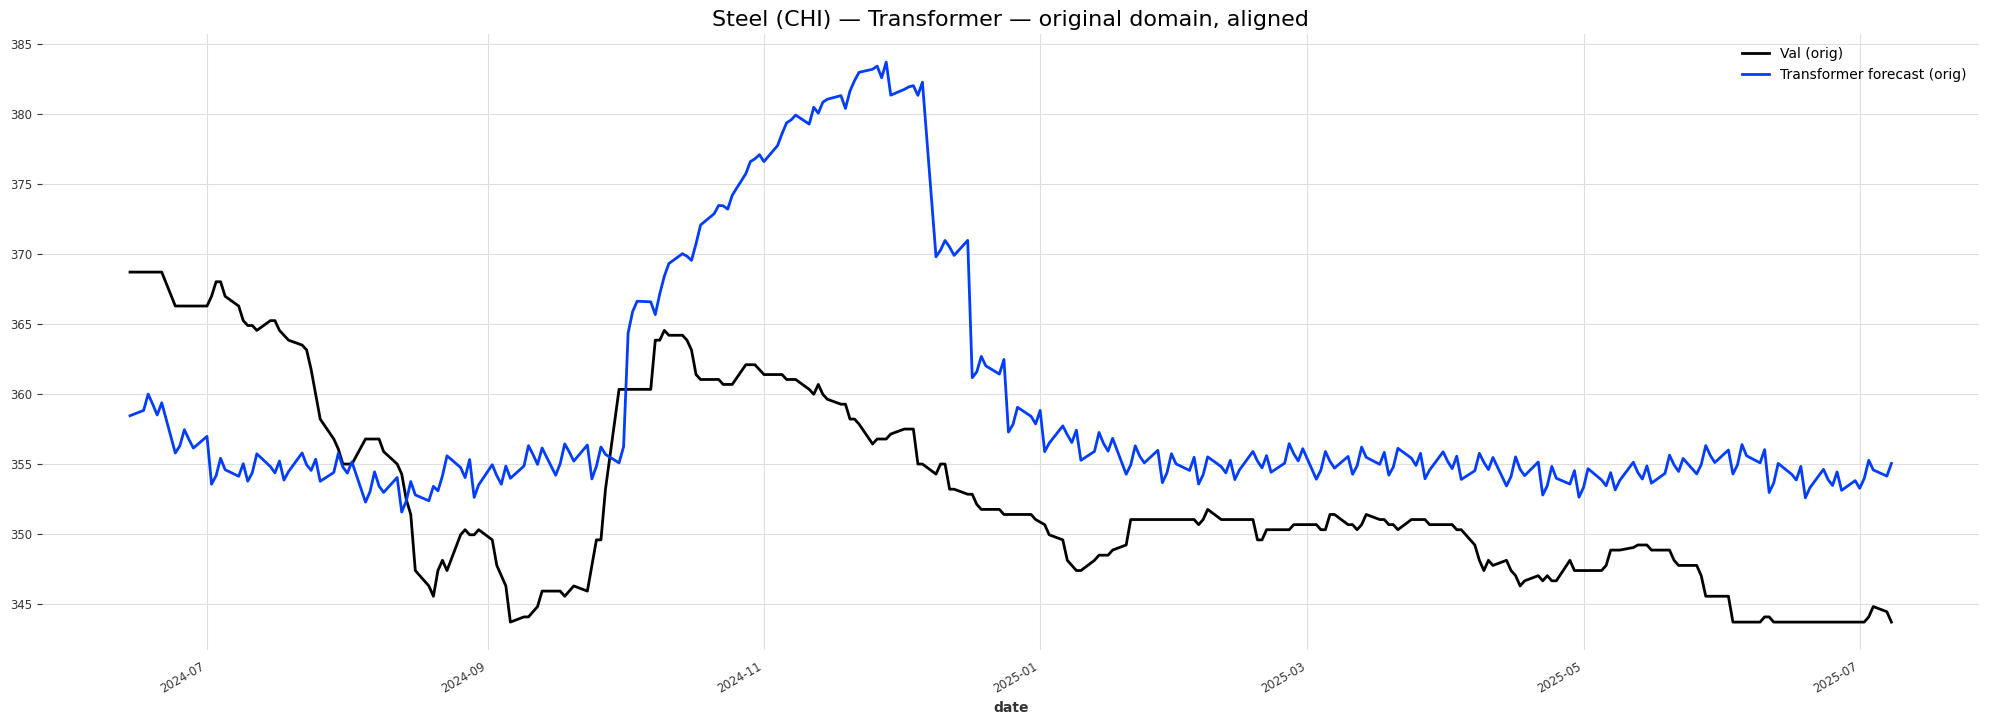

In [19]:
# ============================================
# Best run
# ============================================

result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
trans_opt_df = pd.read_excel(excel_file_path, sheet_name='trans_opt')
best = trans_opt_df.iloc[0]

input_chunk_length = int(best["input_chunk_length"])
output_chunk_length = int(best["output_chunk_length"])
d_model, nhead = best["d_model"], best["nhead"] 
num_encoder_layers = int(best["encoder_layers"])
num_decoder_layers = int(best["decoder_layers"])
dim_feedforward = int(best["dim_feedforward"])
dropout = float(best["dropout"])
lr = float(best["lr"])
weight_decay = float(best.get("weight_decay", 0.0))
use_likelihood = bool(best["use_likelihood"])
activation = best["activation"]

loss_name = best["loss_fn"]
loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()

likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None
batch_size = 64
n_epochs = 500

covs_train_best, covs_val_best, _ = prepare_covariates_flexible(
    covariates=covariates_all,
    ref_series=series_scaled_aligned,
    train_size=train_size,
    input_chunk_length=input_chunk_length,
    scaler_covs=None,
)

stopper = EarlyStopping(monitor="val_loss", patience=25, min_delta=0.001, mode='min', verbose=False)
lr_scheduler = ReduceLROnPlateau

final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
final_pl_kwargs["callbacks"] = [stopper]

other_torch_kwargs = torch_kwargs.copy()
other_torch_kwargs.pop("pl_trainer_kwargs", None)

best_model = TransformerModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    d_model=d_model,
    nhead=nhead,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    dim_feedforward=dim_feedforward,
    dropout=dropout,
    batch_size=batch_size,
    n_epochs=n_epochs,
    likelihood=likelihood,
    optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
    random_state=42,
    activation=activation,
    loss_fn=loss_fn,
    force_reset=True,
    save_checkpoints=True,
    lr_scheduler_cls=lr_scheduler,
    lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False},
    pl_trainer_kwargs=final_pl_kwargs,
    **other_torch_kwargs
)


print("Training the best model...")
start_time = time.time()

best_model.fit(
    series=train_scaled, 
    past_covariates=covs_train_best,
    val_series=val_scaled,
    val_past_covariates=covs_val_best,
    verbose=False
)

print("Predicting...")
prediction = (
    best_model.predict(n=len(val_scaled), past_covariates=covs_val_best, num_samples=300)
    if best_model.likelihood is not None
    else best_model.predict(n=len(val_scaled), past_covariates=covs_val_best)
)
exec_time = round(time.time() - start_time, 4)

# Metrics
mets = metrics_on_original_domain(
    y_val_scaled=val_scaled,
    y_pred=prediction,
    y_train_scaled=train_scaled,
    scaler_target=scaler,
    reduce_to_median=True,
)

pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
val_trans  = scaler.inverse_transform(val_scaled)
pred_trans = scaler.inverse_transform(pred_point)
val_orig   = inverse_transform(val_trans)
pred_orig  = inverse_transform(pred_trans)
rmsle_val  = rmsle(val_orig, pred_orig)

print("\nBest Model Metrics:")
print(f"MAE(orig):   {mets['mae']:.4f}")
print(f"MSE(orig):   {mets['mse']:.4f}")
print(f"RMSE(orig):  {mets['rmse']:.4f}")
print(f"RMSLE(orig): {rmsle_val:.4f}")
print(f"MAPE(orig):  {mets['mape']:.4f}")
print(f"SMAPE(orig): {mets['smape']:.4f}")
print(f"Time:        {exec_time}")

# ============================================
# Summary
# ============================================
sheet_name_summary = "summary_chi"
new_row = {
    'Dataset': 'Steel (CHI)',
    'Model': 'Transformer',
    'MAE': mets['mae'],
    'MSE': mets['mse'],
    'RMSE': mets['rmse'],
    'RMSLE': rmsle_val,
    'MAPE': mets['mape'],
    'SMAPE': mets['smape'],
    'MASE': mets.get('mase', np.nan),
    'MARRE': mets['marre'],
    'Time': exec_time
}

try:
    summary_df = pd.read_excel(excel_file_path, sheet_name=sheet_name_summary)
    mask = (summary_df['Dataset'] == new_row['Dataset']) & (summary_df['Model'] == new_row['Model'])
    if mask.any():
        summary_df.loc[mask, list(new_row.keys())[2:]] = list(new_row.values())[2:]
        print("Updated: Transformer")
    else:
        summary_df = pd.concat([summary_df, pd.DataFrame([new_row])], ignore_index=True)
        print("Add new model: Transformer")
except (FileNotFoundError, ValueError):
    summary_df = pd.DataFrame([new_row])
    print("Created new Summary (sheet/file).")

with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name_summary, index=False)

# ============================================
# Errors DF
# ============================================
eps = 1e-12
common_start = max(val_orig.start_time(), pred_orig.start_time())
common_end   = min(val_orig.end_time(),   pred_orig.end_time())
val_common   = val_orig.slice(common_start, common_end)
pred_common  = pred_orig.slice(common_start, common_end)

y_true = val_common.univariate_values()
y_hat  = pred_common.univariate_values()
dates  = val_common.time_index

df_new = pd.DataFrame({
    "date": dates,
    "trans_pred":  y_hat,
    "trans_error": np.abs(y_hat - y_true),
    "trans_smape": 100 * (2.0 * np.abs(y_true - y_hat) /
                          (np.abs(y_true) + np.abs(y_hat) + eps))
})

sheet_name_err = "error_chi"
try:
    old = pd.read_excel(excel_file_path, sheet_name=sheet_name_err)
    if "date" in old.columns:
        old["date"] = pd.to_datetime(old["date"])
    else:
        old = pd.DataFrame({"date": df_new["date"]})
    merged = pd.merge(old, df_new, on="date", how="outer")
    merged.sort_values("date", inplace=True)
except (ValueError, FileNotFoundError):
    merged = df_new

with pd.ExcelWriter(excel_file_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    merged.to_excel(writer, sheet_name=sheet_name_err, index=False)

print(f"'error_chi' updated (aligned by date)!")

# ============================================
# Plot
# ============================================
plt.figure(figsize=(25, 8))
val_common.plot(label="Val (orig)")
pred_common.plot(label="Transformer forecast (orig)")
plt.title("Steel (CHI) — Transformer — original domain, aligned", fontsize=16)
plt.legend(); plt.grid(True); plt.show()

## N-HiTS

In [7]:
# ============================================
# N-HiTS
# ============================================

# useful for GPU/seed
torch_kwargs = {}
if "generate_torch_kwargs" in globals() and callable(globals()["generate_torch_kwargs"]):
    try:
        torch_kwargs = generate_torch_kwargs()
    except Exception:
        torch_kwargs = {}


optuna_results = []
lr_scheduler = ReduceLROnPlateau

def objective(trial):
    # ---------------------------
    # Hyperparameters
    # ---------------------------
    input_chunk_length = trial.suggest_int("input_chunk_length", 32, 128, step=32)
    ocl_min = max(5, input_chunk_length // 10)
    ocl_max = max(10, input_chunk_length // 4)
    if ocl_min > ocl_max:
        ocl_min, ocl_max = ocl_max, ocl_min
    output_chunk_length = trial.suggest_int("output_chunk_length", ocl_min, ocl_max)

    if len(val_scaled) < input_chunk_length + output_chunk_length:
        raise optuna.exceptions.TrialPruned()

    num_stacks = trial.suggest_int("num_stacks", 2, 4)
    num_blocks = trial.suggest_int("num_blocks", 1, 3)
    num_layers_in_block = trial.suggest_int("num_layers_in_block", 1, 3)
    layer_width = trial.suggest_categorical("layer_width", [128, 256, 512])

    n_freq_downsample = []
    for i in range(num_stacks):
        if i < num_stacks - 1:
            factor = trial.suggest_int(f"n_freq_downsample_stack_{i}", 1, 4)
            n_freq_downsample.append([factor] * num_blocks)
        else:
            n_freq_downsample.append([1] * num_blocks)

    activation = trial.suggest_categorical("activation", ["ReLU", "GELU"])
    loss_name = trial.suggest_categorical("loss_fn", ["mse", "huber"])
    loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
    use_likelihood = trial.suggest_categorical("use_likelihood", [True, False])
    likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None
    dropout = trial.suggest_float("dropout", 0.0, 0.3)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-4, log=True)
    stopper = EarlyStopping(monitor="val_loss", patience=25, min_delta=0.001, verbose=False, mode='min')

    # ---------------------------
    # Covariates
    # ---------------------------
    covs_train, covs_val, _ = prepare_covariates_flexible(
        covariates=covariates_all, ref_series=series_scaled_aligned, train_size=train_size,
        input_chunk_length=input_chunk_length, scaler_covs=None,
    )

    # ---------------------------
    # Model
    # ---------------------------
    final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
    final_pl_kwargs["callbacks"] = [stopper]
    other_torch_kwargs = torch_kwargs.copy()
    other_torch_kwargs.pop("pl_trainer_kwargs", None)
    
    model = NHiTSModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=output_chunk_length,
        num_stacks=num_stacks,
        num_blocks=num_blocks,
        num_layers=num_layers_in_block,
        layer_widths=layer_width,
        n_freq_downsample=n_freq_downsample,
        activation=activation,
        dropout=dropout,
        batch_size=64,
        n_epochs=500,
        likelihood=likelihood,
        optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
        random_state=42,
        force_reset=True,
        save_checkpoints=True,
        loss_fn=loss_fn, 
        lr_scheduler_cls=lr_scheduler,
        lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False},
        pl_trainer_kwargs=final_pl_kwargs,
        **other_torch_kwargs
    )

    try:
        start_time = time.time()

        model.fit(
            series=train_scaled,
            past_covariates=covs_train,
            val_series=val_scaled,
            val_past_covariates=covs_val,
            verbose=False
        )

        prediction = model.predict(
            n=len(val_scaled),
            past_covariates=covs_val,
            num_samples=300 if use_likelihood else 1
        )
        
        exec_time = round(time.time() - start_time, 4)

        mets = metrics_on_original_domain(
            y_val_scaled=val_scaled, y_pred=prediction, y_train_scaled=train_scaled,
            scaler_target=scaler, reduce_to_median=True,
        )
        pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
        val_trans = scaler.inverse_transform(val_scaled)
        pred_trans = scaler.inverse_transform(pred_point)
        val_orig = inverse_transform(val_trans)
        pred_orig = inverse_transform(pred_trans)
        rmsle_val = rmsle(val_orig, pred_orig)
        
        optuna_results.append({
            "trial": trial.number, 
            "input_chunk_length": input_chunk_length,
            "output_chunk_length": output_chunk_length, 
            "num_stacks": num_stacks,
            "num_blocks": num_blocks, 
            "layer_widths": layer_width, 
            "activation": activation,
            "n_freq_downsample": str(n_freq_downsample),
            "num_layers_in_block": num_layers_in_block,
            "dropout": dropout, 
            "lr": lr, 
            "weight_decay": weight_decay,
            "loss_fn": loss_name, 
            "use_likelihood": use_likelihood,
            "mae": mets["mae"], 
            "mse": mets["mse"], 
            "rmse": mets["rmse"],
            "rmsle": rmsle_val, 
            "mape": mets["mape"], 
            "smape": mets["smape"],
            "mase": mets.get("mase", np.nan), 
            "marre": mets["marre"], 
            "time": exec_time
        })
        print(f"Trial {trial.number} | sMAPE(orig): {mets['smape']:.4f} | t={exec_time}s")
        return mets["smape"]

    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return float("inf")
    
# ============================
# Run Optuna
# ============================
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

nhits_opt = pd.DataFrame(optuna_results).sort_values(by="smape").reset_index(drop=True)

# Save Results
result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')

if os.path.exists(excel_file_path):
    try:
        with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            nhits_opt.to_excel(writer, sheet_name='nhits_opt', index=False)
    except Exception as e:
        print(f"Error adding the sheet 'nhits_opt': {e}")
else:
    with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='w') as writer:
        nhits_opt.to_excel(writer, sheet_name='nhits_opt', index=False)


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 0 | sMAPE(orig): 5.9754 | t=14.7657s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 1 | sMAPE(orig): 3.3968 | t=19.7748s


Predicting: |          | 0/? [00:00<?, ?it/s]

...

Trial 47 | sMAPE(orig): 4.8500 | t=36.9933s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 48 | sMAPE(orig): 6.1121 | t=21.9461s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 49 | sMAPE(orig): 3.2849 | t=86.6459s


Training the best model N-HiTS...
Predicting...


Predicting: |          | 0/? [00:00<?, ?it/s]


Best Model Metrics N-HiTS:
MAE(orig):   9.1565
MSE(orig):   121.3768
RMSE(orig):  11.0171
RMSLE(orig): 0.0306
MAPE(orig):  2.5971%
SMAPE(orig): 2.5571%
Time:        86.1095s
Updated: N-HiTS
'error_chi' updated (aligned by date)!


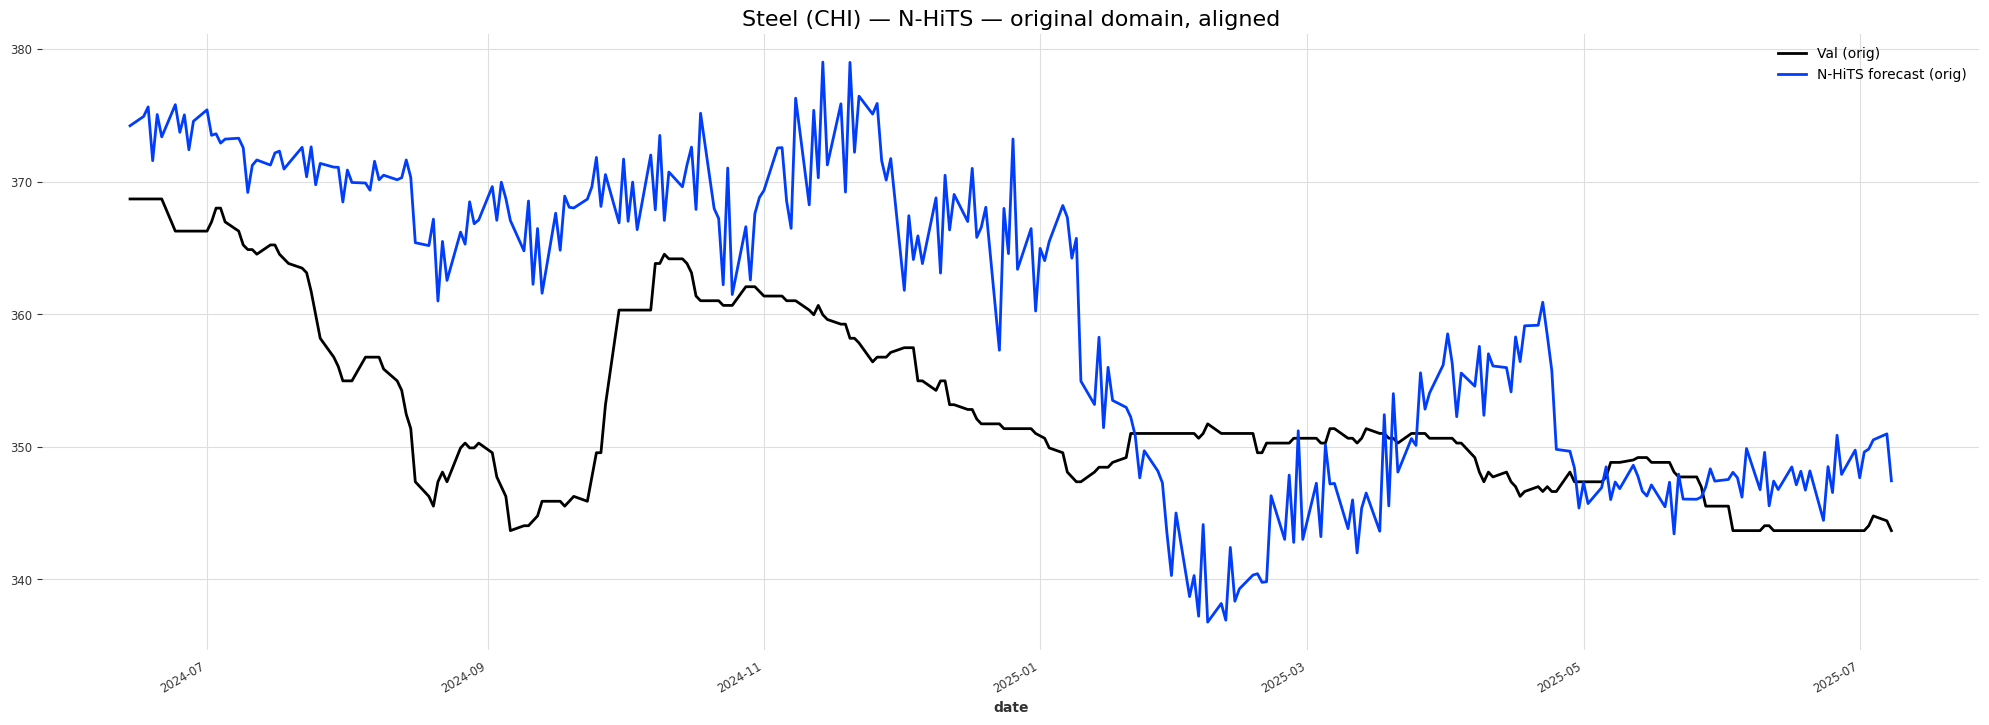

In [8]:
# ============================================
# Best run N-HiTS
# ============================================

result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
nhits_opt_df = pd.read_excel(excel_file_path, sheet_name='nhits_opt')
best = nhits_opt_df.iloc[0]

input_chunk_length = int(best["input_chunk_length"])
output_chunk_length = int(best["output_chunk_length"])
num_stacks = int(best["num_stacks"])
num_blocks = int(best["num_blocks"])
dropout = float(best["dropout"])
lr = float(best["lr"])
weight_decay = float(best.get("weight_decay", 0.0))
layer_width = int(best["layer_widths"])
num_layers_in_block = int(best["num_layers_in_block"])
activation = best["activation"]
loss_name = best["loss_fn"]
loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
use_likelihood = bool(best["use_likelihood"])
likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None

n_freq_downsample = ast.literal_eval(best["n_freq_downsample"])

batch_size = 64
n_epochs = 500

covs_train_best, covs_val_best, _ = prepare_covariates_flexible(
    covariates=covariates_all,
    ref_series=series_scaled_aligned,
    train_size=train_size,
    input_chunk_length=input_chunk_length,
    scaler_covs=None,
)

stopper = EarlyStopping(monitor="val_loss", patience=25, min_delta=0.001, mode='min', verbose=False)
lr_scheduler = ReduceLROnPlateau

final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
final_pl_kwargs["callbacks"] = [stopper]

other_torch_kwargs = torch_kwargs.copy()
other_torch_kwargs.pop("pl_trainer_kwargs", None)

best_model = NHiTSModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    num_stacks=num_stacks,
    num_blocks=num_blocks,
    num_layers=num_layers_in_block,
    layer_widths=layer_width,
    n_freq_downsample=n_freq_downsample,
    dropout=dropout,
    activation=activation, 
    batch_size=batch_size, 
    n_epochs=n_epochs,
    likelihood=likelihood, 
    optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
    random_state=42,
    force_reset=True,
    save_checkpoints=True,
    loss_fn=loss_fn,       
    lr_scheduler_cls=lr_scheduler, 
    lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False}, 
    pl_trainer_kwargs=final_pl_kwargs, 
    **other_torch_kwargs
)

print("Training the best model N-HiTS...")
start_time = time.time()

best_model.fit(
    series=train_scaled, 
    past_covariates=covs_train_best,
    val_series=val_scaled,
    val_past_covariates=covs_val_best,
    verbose=False
)

print("Predicting...")
prediction = (
    best_model.predict(n=len(val_scaled), past_covariates=covs_val_best, num_samples=300)
    if use_likelihood
    else best_model.predict(n=len(val_scaled), past_covariates=covs_val_best)
)
exec_time = round(time.time() - start_time, 4)

# Metrics
mets = metrics_on_original_domain(
    y_val_scaled=val_scaled,
    y_pred=prediction,
    y_train_scaled=train_scaled,
    scaler_target=scaler,
    reduce_to_median=True,
)

pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
val_trans  = scaler.inverse_transform(val_scaled)
pred_trans = scaler.inverse_transform(pred_point)
val_orig   = inverse_transform(val_trans)
pred_orig  = inverse_transform(pred_trans)
rmsle_val  = rmsle(val_orig, pred_orig)

print("\nBest Model Metrics N-HiTS:")
print(f"MAE(orig):   {mets['mae']:.4f}")
print(f"MSE(orig):   {mets['mse']:.4f}")
print(f"RMSE(orig):  {mets['rmse']:.4f}")
print(f"RMSLE(orig): {rmsle_val:.4f}")
print(f"MAPE(orig):  {mets['mape']:.4f}%")
print(f"SMAPE(orig): {mets['smape']:.4f}%")
print(f"Time:        {exec_time}s")

# ============================================
# Summary
# ============================================
sheet_name_summary = "summary_chi"
new_row = {
    'Dataset': 'Steel (CHI)',
    'Model': 'N-HiTS',
    'MAE': mets['mae'],
    'MSE': mets['mse'],
    'RMSE': mets['rmse'],
    'RMSLE': rmsle_val,
    'MAPE': mets['mape'],
    'SMAPE': mets['smape'],
    'MASE': mets.get('mase', np.nan),
    'MARRE': mets['marre'],
    'Time': exec_time
}

try:
    summary_df = pd.read_excel(excel_file_path, sheet_name=sheet_name_summary)
    mask = (summary_df['Dataset'] == new_row['Dataset']) & (summary_df['Model'] == new_row['Model'])
    if mask.any():
        summary_df.loc[mask, list(new_row.keys())[2:]] = list(new_row.values())[2:]
        print("Updated: N-HiTS")
    else:
        summary_df = pd.concat([summary_df, pd.DataFrame([new_row])], ignore_index=True)
        print("Add new model: N-HiTS")
except (FileNotFoundError, ValueError):
    summary_df = pd.DataFrame([new_row])
    print("Created new Summary (sheet/file).")

with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name_summary, index=False)

# ============================================
# Errors DF
# ============================================
eps = 1e-12
common_start = max(val_orig.start_time(), pred_orig.start_time())
common_end   = min(val_orig.end_time(),   pred_orig.end_time())
val_common   = val_orig.slice(common_start, common_end)
pred_common  = pred_orig.slice(common_start, common_end)

y_true = val_common.univariate_values()
y_hat  = pred_common.univariate_values()
dates  = val_common.time_index

df_new = pd.DataFrame({
    "date": dates,
    "nhits_pred":  y_hat,
    "nhits_error": np.abs(y_hat - y_true),
    "nhits_smape": 100 * (2.0 * np.abs(y_true - y_hat) /
                          (np.abs(y_true) + np.abs(y_hat) + eps))
})

sheet_name_err = "error_chi"
try:
    old = pd.read_excel(excel_file_path, sheet_name=sheet_name_err)
    if "date" in old.columns:
        old["date"] = pd.to_datetime(old["date"])
    else:
        old = pd.DataFrame({"date": df_new["date"]})
    merged = pd.merge(old, df_new, on="date", how="outer")
    merged.sort_values("date", inplace=True)
except (ValueError, FileNotFoundError):
    merged = df_new

with pd.ExcelWriter(excel_file_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    merged.to_excel(writer, sheet_name=sheet_name_err, index=False)

print(f"'error_chi' updated (aligned by date)!")

# ============================================
# Plot
# ============================================
plt.figure(figsize=(25, 8))
val_common.plot(label="Val (orig)")
pred_common.plot(label="N-HiTS forecast (orig)")
plt.title("Steel (CHI) — N-HiTS — original domain, aligned", fontsize=16)
plt.legend(); plt.grid(True); plt.show()

## D-Linear

In [9]:
# ============================================
# DLinear
# ============================================

# useful for GPU/seed
torch_kwargs = {}
if "generate_torch_kwargs" in globals() and callable(globals()["generate_torch_kwargs"]):
    try:
        torch_kwargs = generate_torch_kwargs()
    except Exception:
        torch_kwargs = {}

optuna_results = []

lr_scheduler = ReduceLROnPlateau

def objective(trial):
    # ---------------------------
    # Hyperparameters
    # ---------------------------
    input_chunk_length = trial.suggest_int("input_chunk_length", 32, 128, step=32)

    ocl_min = max(5, input_chunk_length // 10)
    ocl_max = max(10, input_chunk_length // 4)
    if ocl_min > ocl_max:
        ocl_min, ocl_max = ocl_max, ocl_min
    output_chunk_length = trial.suggest_int("output_chunk_length", ocl_min, ocl_max)

    if len(val_scaled) < input_chunk_length + output_chunk_length:
        raise optuna.exceptions.TrialPruned()

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    kernel_size = trial.suggest_int("kernel_size", 5, 25, step=4)
    shared_weights = trial.suggest_categorical("shared_weights", [False, True])
    const_init = trial.suggest_categorical("const_init", [True, False])
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-4, log=True)
    loss_name = trial.suggest_categorical("loss_fn", ["mse", "huber"])
    loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
    use_likelihood = trial.suggest_categorical("use_likelihood", [True, False])
    likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None

    stopper = EarlyStopping(
        monitor="val_loss", patience=25, min_delta=0.001, verbose=False, mode='min'
    )

    # ---------------------------
    # Model
    # ---------------------------
    final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
    final_pl_kwargs["callbacks"] = [stopper]

    other_torch_kwargs = torch_kwargs.copy()
    other_torch_kwargs.pop("pl_trainer_kwargs", None)
    
    model = DLinearModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=output_chunk_length,
        kernel_size=kernel_size,
        shared_weights=shared_weights,
        const_init=const_init,
        batch_size=64,
        n_epochs=500, 
        likelihood=likelihood,
        optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
        random_state=42,
        force_reset=True,
        save_checkpoints=True,
        loss_fn=loss_fn, 
        lr_scheduler_cls=lr_scheduler,
        lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False},
        pl_trainer_kwargs=final_pl_kwargs,
        **other_torch_kwargs
    )
    
    try:
        start_time = time.time()

        model.fit(
            series=train_scaled,
            val_series=val_scaled,
            verbose=False
        )

        prediction = model.predict(
            n=len(val_scaled),
            num_samples=300 if use_likelihood else 1
        )
        exec_time = round(time.time() - start_time, 4)

        
        mets = metrics_on_original_domain(
            y_val_scaled=val_scaled, y_pred=prediction, y_train_scaled=train_scaled,
            scaler_target=scaler, reduce_to_median=True,
        )
        pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
        val_trans = scaler.inverse_transform(val_scaled)
        pred_trans = scaler.inverse_transform(pred_point)
        val_orig = inverse_transform(val_trans)
        pred_orig = inverse_transform(pred_trans)
        rmsle_val = rmsle(val_orig, pred_orig)
        
        optuna_results.append({
            "trial": trial.number, 
            "input_chunk_length": input_chunk_length,
            "output_chunk_length": output_chunk_length, 
            "lr": lr,
            "kernel_size": kernel_size, 
            "shared_weights": shared_weights,
            "const_init": const_init, 
            "weight_decay": weight_decay,
            "loss_fn": loss_name, 
            "use_likelihood": use_likelihood,
            "mae": mets["mae"], 
            "mse": mets["mse"], 
            "rmse": mets["rmse"],
            "rmsle": rmsle_val, 
            "mape": mets["mape"], 
            "smape": mets["smape"],
            "mase": mets.get("mase", np.nan), 
            "marre": mets["marre"], 
            "time": exec_time
        })
        print(f"Trial {trial.number} | sMAPE(orig): {mets['smape']:.4f} | t={exec_time}s")
        return mets["smape"]

    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return float("inf")

# ============================
# Run Optuna
# ============================
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

dlinear_opt = pd.DataFrame(optuna_results).sort_values(by="smape").reset_index(drop=True)

# Save Results
result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')

if os.path.exists(excel_file_path):
    try:
        with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            dlinear_opt.to_excel(writer, sheet_name='dlinear_opt', index=False)
    except Exception as e:
        print(f"Error adding the sheet 'dlinear_opt': {e}")
else:
    with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='w') as writer:
        dlinear_opt.to_excel(writer, sheet_name='dlinear_opt', index=False)

Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 0 | sMAPE(orig): 4.9513 | t=5.5732s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 1 | sMAPE(orig): 5.0927 | t=12.8705s


Predicting: |          | 0/? [00:00<?, ?it/s]

...

Trial 47 | sMAPE(orig): 3.3006 | t=6.0795s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 48 | sMAPE(orig): 4.1249 | t=11.2552s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 49 | sMAPE(orig): 3.5172 | t=5.4741s


Training the best model DLinear...
Predicting...


Predicting: |          | 0/? [00:00<?, ?it/s]


Best Model Metrics DLinear:
MAE(orig):   3.9751
MSE(orig):   31.0071
RMSE(orig):  5.5684
RMSLE(orig): 0.0157
MAPE(orig):  1.1363%
SMAPE(orig): 1.1242%
Time:        12.1841s
Updated: DLinear
'error_chi' updated (aligned by date)!


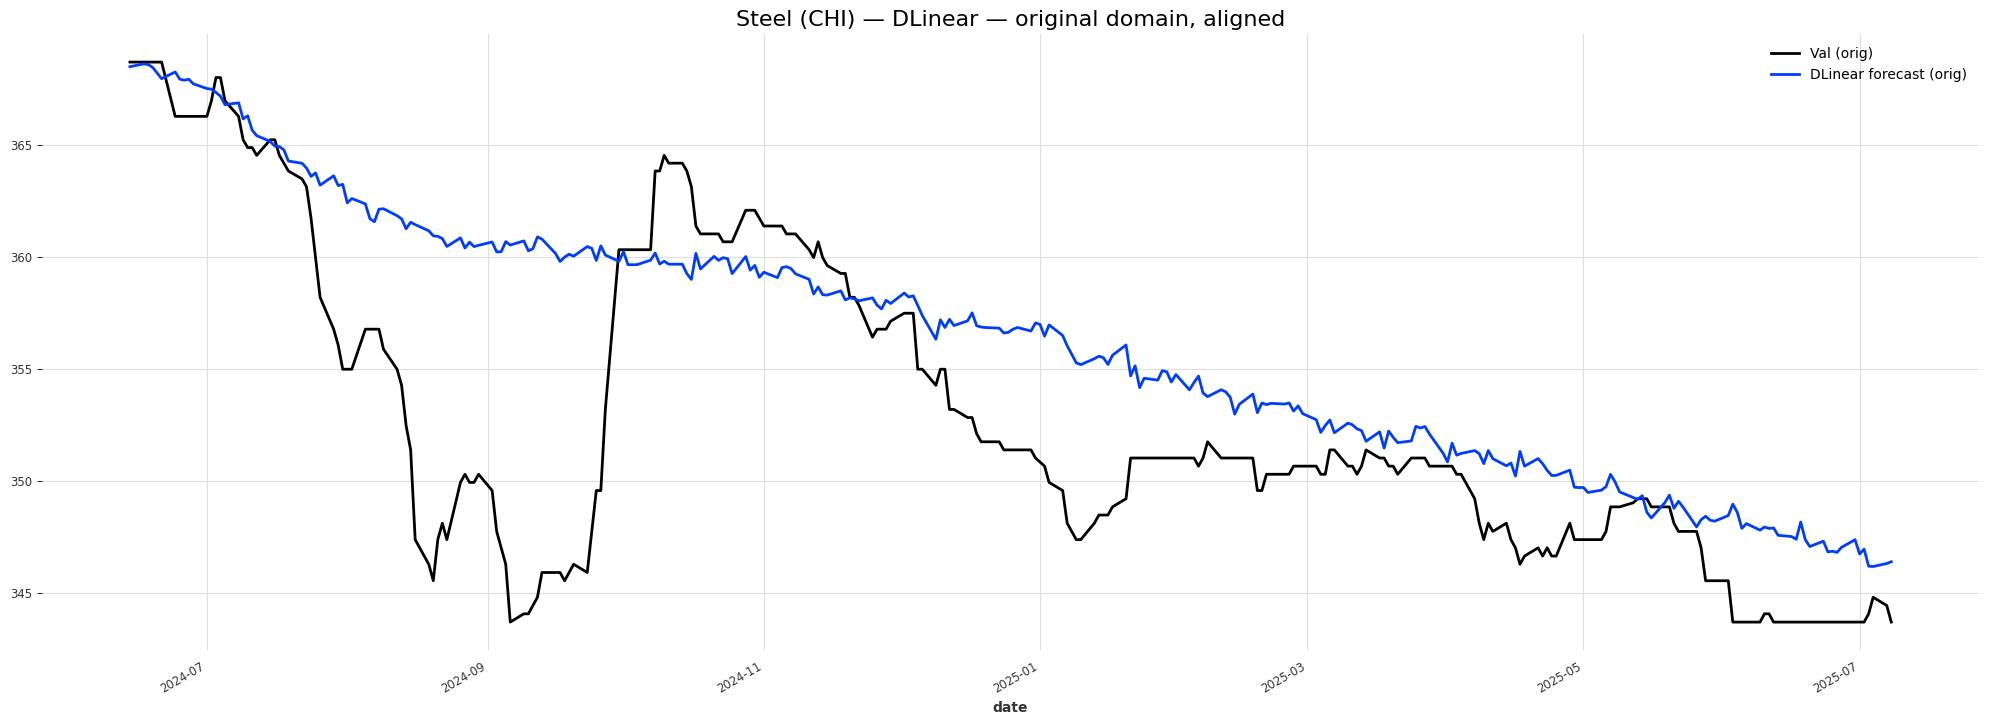

In [10]:
# ============================================
# Best run DLinear
# ============================================

result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
dlinear_opt_df = pd.read_excel(excel_file_path, sheet_name='dlinear_opt')
best = dlinear_opt_df.iloc[0]

input_chunk_length = int(best["input_chunk_length"])
output_chunk_length = int(best["output_chunk_length"])
lr = float(best["lr"])
kernel_size = int(best["kernel_size"])
shared_weights = bool(best["shared_weights"])
const_init = bool(best["const_init"])
weight_decay = float(best.get("weight_decay", 0.0))


loss_name = best["loss_fn"]
loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
use_likelihood = bool(best["use_likelihood"])
likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None


batch_size = 64
n_epochs = 500  

stopper = EarlyStopping(monitor="val_loss", patience=25, min_delta=0.001, mode='min', verbose=False)
lr_scheduler = ReduceLROnPlateau

final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
final_pl_kwargs["callbacks"] = [stopper]

other_torch_kwargs = torch_kwargs.copy()
other_torch_kwargs.pop("pl_trainer_kwargs", None)

best_model = DLinearModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    kernel_size=kernel_size,
    shared_weights=shared_weights,
    const_init=const_init,
    batch_size=batch_size, 
    n_epochs=n_epochs,     
    likelihood=likelihood, 
    optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
    random_state=42,
    force_reset=True,
    save_checkpoints=True,
    loss_fn=loss_fn,       

    lr_scheduler_cls=lr_scheduler, 
    lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False}, 
    pl_trainer_kwargs=final_pl_kwargs, 
    **other_torch_kwargs
)

print("Training the best model DLinear...")
start_time = time.time()

best_model.fit(
    series=train_scaled,
    val_series=val_scaled,
    verbose=False
)

print("Predicting...")
prediction = (
    best_model.predict(n=len(val_scaled), num_samples=300)
    if use_likelihood
    else best_model.predict(n=len(val_scaled))
)
exec_time = round(time.time() - start_time, 4)

# Metrics
mets = metrics_on_original_domain(
    y_val_scaled=val_scaled,
    y_pred=prediction,
    y_train_scaled=train_scaled,
    scaler_target=scaler,
    reduce_to_median=True,
)

pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
val_trans  = scaler.inverse_transform(val_scaled)
pred_trans = scaler.inverse_transform(pred_point)
val_orig   = inverse_transform(val_trans)
pred_orig  = inverse_transform(pred_trans)
rmsle_val  = rmsle(val_orig, pred_orig)

print("\nBest Model Metrics DLinear:")
print(f"MAE(orig):   {mets['mae']:.4f}")
print(f"MSE(orig):   {mets['mse']:.4f}")
print(f"RMSE(orig):  {mets['rmse']:.4f}")
print(f"RMSLE(orig): {rmsle_val:.4f}")
print(f"MAPE(orig):  {mets['mape']:.4f}%")
print(f"SMAPE(orig): {mets['smape']:.4f}%")
print(f"Time:        {exec_time}s")

# ============================================
# Summary
# ============================================
sheet_name_summary = "summary_chi"
new_row = {
    'Dataset': 'Steel (CHI)',
    'Model': 'DLinear',
    'MAE': mets['mae'],
    'MSE': mets['mse'],
    'RMSE': mets['rmse'],
    'RMSLE': rmsle_val,
    'MAPE': mets['mape'],
    'SMAPE': mets['smape'],
    'MASE': mets.get('mase', np.nan),
    'MARRE': mets['marre'],
    'Time': exec_time
}

try:
    summary_df = pd.read_excel(excel_file_path, sheet_name=sheet_name_summary)
    mask = (summary_df['Dataset'] == new_row['Dataset']) & (summary_df['Model'] == new_row['Model'])
    if mask.any():
        summary_df.loc[mask, list(new_row.keys())[2:]] = list(new_row.values())[2:]
        print("Updated: DLinear")
    else:
        summary_df = pd.concat([summary_df, pd.DataFrame([new_row])], ignore_index=True)
        print("Add new model: DLinear")
except (FileNotFoundError, ValueError):
    summary_df = pd.DataFrame([new_row])
    print("Created new Summary (sheet/file).")

with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name_summary, index=False)

# ============================================
# Errors DF
# ============================================
eps = 1e-12
common_start = max(val_orig.start_time(), pred_orig.start_time())
common_end   = min(val_orig.end_time(),   pred_orig.end_time())
val_common   = val_orig.slice(common_start, common_end)
pred_common  = pred_orig.slice(common_start, common_end)

y_true = val_common.univariate_values()
y_hat  = pred_common.univariate_values()
dates  = val_common.time_index

df_new = pd.DataFrame({
    "date": dates,
    "dlinear_pred":  y_hat,
    "dlinear_error": np.abs(y_hat - y_true),
    "dlinear_smape": 100 * (2.0 * np.abs(y_true - y_hat) /
                            (np.abs(y_true) + np.abs(y_hat) + eps))
})

sheet_name_err = "error_chi"
try:
    old = pd.read_excel(excel_file_path, sheet_name=sheet_name_err)
    if "date" in old.columns:
        old["date"] = pd.to_datetime(old["date"])
    else:
        old = pd.DataFrame({"date": df_new["date"]})
    merged = pd.merge(old, df_new, on="date", how="outer")
    merged.sort_values("date", inplace=True)
except (ValueError, FileNotFoundError):
    merged = df_new

with pd.ExcelWriter(excel_file_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    merged.to_excel(writer, sheet_name=sheet_name_err, index=False)

print(f"'error_chi' updated (aligned by date)!")

# ============================================
# Plot
# ============================================
plt.figure(figsize=(25, 8))
val_common.plot(label="Val (orig)")
pred_common.plot(label="DLinear forecast (orig)")
plt.title("Steel (CHI) — DLinear — original domain, aligned", fontsize=16)
plt.legend(); plt.grid(True); plt.show()

## TCN

In [11]:
# ============================================
# TCN
# ============================================
import torch
from darts.models import TCNModel
from darts.utils.likelihood_models import QuantileRegression
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from torch.optim.lr_scheduler import ReduceLROnPlateau
import optuna
import pandas as pd
import numpy as np
import os
import time

# useful for GPU/seed
torch_kwargs = {}
if "generate_torch_kwargs" in globals() and callable(globals()["generate_torch_kwargs"]):
    try:
        torch_kwargs = generate_torch_kwargs()
    except Exception:
        torch_kwargs = {}

optuna_results = []

lr_scheduler = ReduceLROnPlateau

def objective(trial):
    # ---------------------------
    # Hyperparameters
    # ---------------------------
    input_chunk_length = trial.suggest_int("input_chunk_length", 32, 128, step=32)
    
    ocl_min = max(6, input_chunk_length // 12)
    ocl_max = max(6, input_chunk_length // 4)
    if ocl_min > ocl_max:
        ocl_min, ocl_max = ocl_max, ocl_min
    output_chunk_length = trial.suggest_int("output_chunk_length", ocl_min, ocl_max)

    if len(val_scaled) < input_chunk_length + output_chunk_length:
        raise optuna.exceptions.TrialPruned()

    kernel_size = trial.suggest_int("kernel_size", 3, 7, step=2)
    num_filters = trial.suggest_int("num_filters", 4, 10, step=2)
    num_layers = trial.suggest_int("num_layers", 2, 5) 
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-4, log=True)
    loss_name = trial.suggest_categorical("loss_fn", ["mse", "huber"])
    loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
    use_likelihood = trial.suggest_categorical("use_likelihood", [True, False])
    likelihood = QuantileRegression(quantiles=[0.05, 0.5, 0.95]) if use_likelihood else None

    # --- CALLBACK - EARLY STOPPING ---
    stopper = EarlyStopping(
        monitor="val_loss", patience=25, min_delta=0.001, verbose=False, mode='min'
    )

    # ---------------------------
    # Covariates
    # ---------------------------
    covs_train, covs_val, _ = prepare_covariates_flexible(
        covariates=covariates_all, ref_series=series_scaled_aligned, train_size=train_size,
        input_chunk_length=input_chunk_length, scaler_covs=None,
    )

    # ---------------------------
    # Model
    # ---------------------------
    final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
    final_pl_kwargs["callbacks"] = [stopper]

    other_torch_kwargs = torch_kwargs.copy()
    other_torch_kwargs.pop("pl_trainer_kwargs", None)

    model = TCNModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=output_chunk_length,
        kernel_size=kernel_size,
        num_filters=num_filters,
        num_layers=num_layers, 
        dilation_base=2,
        weight_norm=True,
        dropout=dropout,
        batch_size=64,
        n_epochs=500, 
        likelihood=likelihood,
        optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
        random_state=42,
        force_reset=True,
        save_checkpoints=True,
        loss_fn=loss_fn, 
        lr_scheduler_cls=lr_scheduler,
        lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False},
        pl_trainer_kwargs=final_pl_kwargs,
        **other_torch_kwargs
    )

    try:
        start_time = time.time()

        model.fit(
            series=train_scaled,
            past_covariates=covs_train,
            val_series=val_scaled,
            val_past_covariates=covs_val,
            verbose=False
        )

        prediction = model.predict(
            n=len(val_scaled),
            past_covariates=covs_val,
            num_samples=300 if use_likelihood else 1
        )
        exec_time = round(time.time() - start_time, 4)

        mets = metrics_on_original_domain(
            y_val_scaled=val_scaled, y_pred=prediction, y_train_scaled=train_scaled,
            scaler_target=scaler, reduce_to_median=True,
        )
        pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
        val_trans = scaler.inverse_transform(val_scaled)
        pred_trans = scaler.inverse_transform(pred_point)
        val_orig = inverse_transform(val_trans)
        pred_orig = inverse_transform(pred_trans)
        rmsle_val = rmsle(val_orig, pred_orig)
        
        optuna_results.append({
            "trial": trial.number, 
            "input_chunk_length": input_chunk_length,
            "output_chunk_length": output_chunk_length, 
            "kernel_size": kernel_size,
            "num_filters": num_filters, 
            "num_layers": num_layers, 
            "dropout": dropout,
            "lr": lr, 
            "weight_decay": weight_decay, 
            "loss_fn": loss_name,
            "use_likelihood": use_likelihood, 
            "mae": mets["mae"], 
            "mse": mets["mse"], 
            "rmse": mets["rmse"], 
            "rmsle": rmsle_val, 
            "mape": mets["mape"], 
            "smape": mets["smape"], 
            "mase": mets.get("mase", np.nan),
            "marre": mets["marre"], 
            "time": exec_time
        })
        print(f"Trial {trial.number} | sMAPE(orig): {mets['smape']:.4f} | t={exec_time}s")
        return mets["smape"]

    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return float("inf")

# ============================
# Run Optuna
# ============================
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

tcn_opt = pd.DataFrame(optuna_results).sort_values(by="smape").reset_index(drop=True)

# Save Results
result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')

if os.path.exists(excel_file_path):
    try:
        with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            tcn_opt.to_excel(writer, sheet_name='tcn_opt', index=False)
    except Exception as e:
        print(f"Error adding the sheet 'tcn_opt': {e}")
else:
    with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='w') as writer:
        tcn_opt.to_excel(writer, sheet_name='tcn_opt', index=False)

Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 0 | sMAPE(orig): 6.0179 | t=12.4175s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 1 | sMAPE(orig): 5.9809 | t=8.5735s


Predicting: |          | 0/? [00:00<?, ?it/s]

...

Trial 47 | sMAPE(orig): 2.0715 | t=9.0945s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 48 | sMAPE(orig): 3.9852 | t=6.2486s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 49 | sMAPE(orig): 6.4564 | t=5.1065s


Training the best model TCN...
Predicting...


Predicting: |          | 0/? [00:00<?, ?it/s]


Best Model Metrics TCN:
MAE(orig):   4.6573
MSE(orig):   28.5623
RMSE(orig):  5.3444
RMSLE(orig): 0.0150
MAPE(orig):  1.3200%
SMAPE(orig): 1.3116%
Time:        8.8039s
Updated: TCN
'error_chi' updated (aligned by date)!


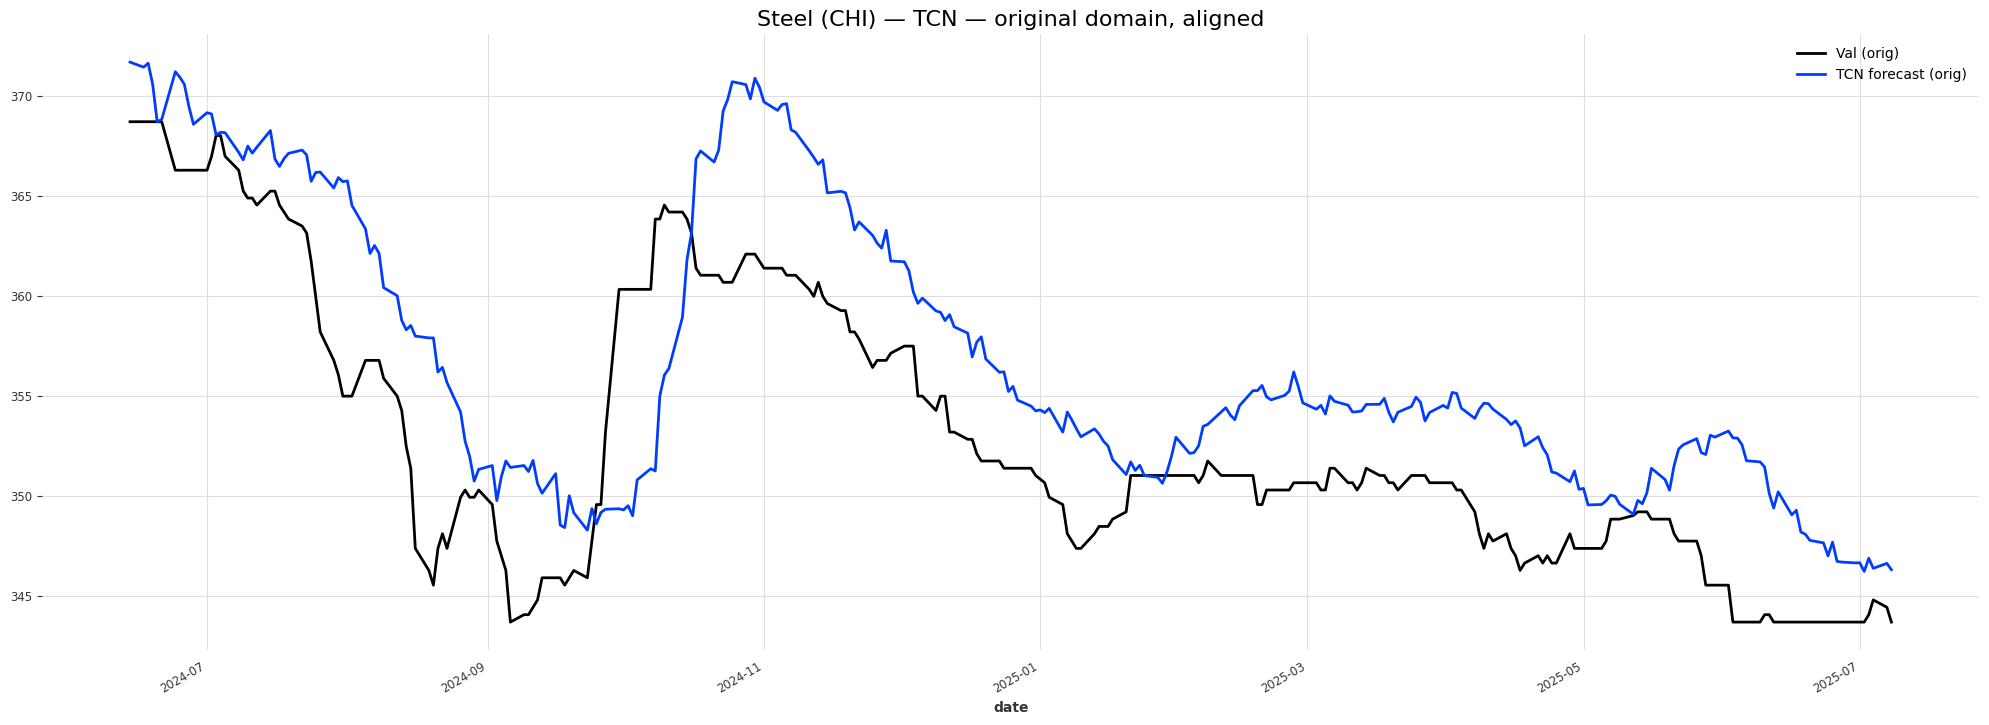

In [12]:
# ============================================
# Best run TCN
# ============================================

result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
tcn_opt_df = pd.read_excel(excel_file_path, sheet_name='tcn_opt')
best = tcn_opt_df.iloc[0]

input_chunk_length = int(best["input_chunk_length"])
output_chunk_length = int(best["output_chunk_length"])
kernel_size = int(best["kernel_size"])
num_filters = int(best["num_filters"])
num_layers = int(best["num_layers"]) 
dropout = float(best["dropout"])
lr = float(best["lr"])
weight_decay = float(best.get("weight_decay", 0.0))

loss_name = best["loss_fn"]
loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
use_likelihood = bool(best["use_likelihood"])
likelihood = QuantileRegression(quantiles=[0.05, 0.5, 0.95]) if use_likelihood else None

batch_size = 64
n_epochs = 500  

covs_train_best, covs_val_best, _ = prepare_covariates_flexible(
    covariates=covariates_all,
    ref_series=series_scaled_aligned,
    train_size=train_size,
    input_chunk_length=input_chunk_length,
    scaler_covs=None,
)

stopper = EarlyStopping(monitor="val_loss", patience=25, min_delta=0.001, mode='min', verbose=False)
lr_scheduler = ReduceLROnPlateau

final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
final_pl_kwargs["callbacks"] = [stopper]

other_torch_kwargs = torch_kwargs.copy()
other_torch_kwargs.pop("pl_trainer_kwargs", None)

best_model = TCNModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    kernel_size=kernel_size,
    num_filters=num_filters,
    num_layers=num_layers, 
    dilation_base=2,
    weight_norm=True,
    dropout=dropout,
    batch_size=batch_size, 
    n_epochs=n_epochs,     
    likelihood=likelihood,
    optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
    random_state=42,
    force_reset=True,
    save_checkpoints=True, 
    loss_fn=loss_fn,       
    lr_scheduler_cls=lr_scheduler, 
    lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False}, 
    pl_trainer_kwargs=final_pl_kwargs, 
    **other_torch_kwargs
)

print("Training the best model TCN...")
start_time = time.time()

best_model.fit(
    series=train_scaled, 
    past_covariates=covs_train_best,
    val_series=val_scaled,
    val_past_covariates=covs_val_best,
    verbose=False
)

print("Predicting...")
prediction = (
    best_model.predict(n=len(val_scaled), past_covariates=covs_val_best, num_samples=300)
    if use_likelihood
    else best_model.predict(n=len(val_scaled), past_covariates=covs_val_best)
)
exec_time = round(time.time() - start_time, 4)

# Metrics
mets = metrics_on_original_domain(
    y_val_scaled=val_scaled,
    y_pred=prediction,
    y_train_scaled=train_scaled,
    scaler_target=scaler,
    reduce_to_median=True,
)

pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
val_trans  = scaler.inverse_transform(val_scaled)
pred_trans = scaler.inverse_transform(pred_point)
val_orig   = inverse_transform(val_trans)
pred_orig  = inverse_transform(pred_trans)
rmsle_val  = rmsle(val_orig, pred_orig)

print("\nBest Model Metrics TCN:")
print(f"MAE(orig):   {mets['mae']:.4f}")
print(f"MSE(orig):   {mets['mse']:.4f}")
print(f"RMSE(orig):  {mets['rmse']:.4f}")
print(f"RMSLE(orig): {rmsle_val:.4f}")
print(f"MAPE(orig):  {mets['mape']:.4f}%")
print(f"SMAPE(orig): {mets['smape']:.4f}%")
print(f"Time:        {exec_time}s")

# ============================================
# Summary
# ============================================
sheet_name_summary = "summary_chi"
new_row = {
    'Dataset': 'Steel (CHI)',
    'Model': 'TCN',
    'MAE': mets['mae'],
    'MSE': mets['mse'],
    'RMSE': mets['rmse'],
    'RMSLE': rmsle_val,
    'MAPE': mets['mape'],
    'SMAPE': mets['smape'],
    'MASE': mets.get('mase', np.nan),
    'MARRE': mets['marre'],
    'Time': exec_time
}

try:
    summary_df = pd.read_excel(excel_file_path, sheet_name=sheet_name_summary)
    mask = (summary_df['Dataset'] == new_row['Dataset']) & (summary_df['Model'] == new_row['Model'])
    if mask.any():
        summary_df.loc[mask, list(new_row.keys())[2:]] = list(new_row.values())[2:]
        print("Updated: TCN")
    else:
        summary_df = pd.concat([summary_df, pd.DataFrame([new_row])], ignore_index=True)
        print("Add new model: TCN")
except (FileNotFoundError, ValueError):
    summary_df = pd.DataFrame([new_row])
    print("Created new Summary (sheet/file).")

with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name_summary, index=False)

# ============================================
# Errors DF
# ============================================
eps = 1e-12
common_start = max(val_orig.start_time(), pred_orig.start_time())
common_end   = min(val_orig.end_time(),   pred_orig.end_time())
val_common   = val_orig.slice(common_start, common_end)
pred_common  = pred_orig.slice(common_start, common_end)

y_true = val_common.univariate_values()
y_hat  = pred_common.univariate_values()
dates  = val_common.time_index

df_new = pd.DataFrame({
    "date": dates,
    "tcn_pred":  y_hat,
    "tcn_error": np.abs(y_hat - y_true),
    "tcn_smape": 100 * (2.0 * np.abs(y_true - y_hat) /
                        (np.abs(y_true) + np.abs(y_hat) + eps))
})

sheet_name_err = "error_chi"
try:
    old = pd.read_excel(excel_file_path, sheet_name=sheet_name_err)
    if "date" in old.columns:
        old["date"] = pd.to_datetime(old["date"])
    else:
        old = pd.DataFrame({"date": df_new["date"]})
    merged = pd.merge(old, df_new, on="date", how="outer")
    merged.sort_values("date", inplace=True)
except (ValueError, FileNotFoundError):
    merged = df_new

with pd.ExcelWriter(excel_file_path, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    merged.to_excel(writer, sheet_name=sheet_name_err, index=False)

print(f"'error_chi' updated (aligned by date)!")

# ============================================
# Plot
# ============================================
plt.figure(figsize=(25, 8))
val_common.plot(label="Val (orig)")
pred_common.plot(label="TCN forecast (orig)")
plt.title("Steel (CHI) — TCN — original domain, aligned", fontsize=16)
plt.legend(); plt.grid(True); plt.show()

## TSMixerModel

In [ ]:
# ============================================
# TSMixer
# ============================================

# useful for GPU/seed
torch_kwargs = {}
if "generate_torch_kwargs" in globals() and callable(globals()["generate_torch_kwargs"]):
    try:
        torch_kwargs = generate_torch_kwargs()
    except Exception:
        torch_kwargs = {}

optuna_results = []

lr_scheduler = ReduceLROnPlateau

def objective(trial):
    # ---------------------------
    # Hyperparameters
    # ---------------------------
    input_chunk_length = trial.suggest_int("input_chunk_length", 12, 64, step=32)
    
    ocl_min = max(3, input_chunk_length // 12)
    ocl_max = max(6, input_chunk_length // 4)
    if ocl_min > ocl_max:
        ocl_min, ocl_max = ocl_max, ocl_min
    output_chunk_length = trial.suggest_int("output_chunk_length", ocl_min, ocl_max)

    if len(val_scaled) < input_chunk_length + output_chunk_length:
        raise optuna.exceptions.TrialPruned()

    hidden_size = trial.suggest_categorical("hidden_size", [128, 256, 512])
    num_blocks = trial.suggest_int("num_blocks", 1, 4)
    ff_size = trial.suggest_categorical("ff_size", [128, 256, 512])
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-4, log=True)
    activation = trial.suggest_categorical("activation", ["ReLU", "GELU"])
    norm_type = trial.suggest_categorical("norm_type", ["LayerNorm", "LayerNormNoBias"])
    loss_name = trial.suggest_categorical("loss_fn", ["mse", "huber"])
    loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
    use_likelihood = trial.suggest_categorical("use_likelihood", [True, False])
    likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None

    # --- CALLBACK - EARLY STOPPING---
    stopper = EarlyStopping(
        monitor="val_loss",
        patience=25,
        min_delta=0.001,
        verbose=False,
        mode='min'
    )

    # ---------------------------
    # Covariates
    # ---------------------------
    covs_train, covs_val, _ = prepare_covariates_flexible(
        covariates=covariates_all,
        ref_series=series_scaled_aligned,
        train_size=train_size,
        input_chunk_length=input_chunk_length,
        scaler_covs=None,
    )

    # ---------------------------
    # Model
    # ---------------------------
    final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
    final_pl_kwargs["callbacks"] = [stopper]

    other_torch_kwargs = torch_kwargs.copy()
    other_torch_kwargs.pop("pl_trainer_kwargs", None)

    model = TSMixerModel(
        input_chunk_length=input_chunk_length,
        output_chunk_length=output_chunk_length,
        hidden_size=hidden_size,
        ff_size=ff_size,
        num_blocks=num_blocks,
        dropout=dropout,
        batch_size=32,
        n_epochs=500,
        likelihood=likelihood,
        optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
        random_state=42,
        force_reset=True,
        save_checkpoints=True,
        activation=activation,
        norm_type=norm_type,
        loss_fn=loss_fn,
        lr_scheduler_cls=lr_scheduler,
        lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False},
        pl_trainer_kwargs=final_pl_kwargs,
        **other_torch_kwargs
    )

    try:
        start_time = time.time()

        model.fit(
            series=train_scaled,
            past_covariates=covs_train,
            val_series=val_scaled,
            val_past_covariates=covs_val,
            verbose=False
        )

        prediction = model.predict(
            n=len(val_scaled),
            past_covariates=covs_val,
            num_samples=300 if use_likelihood else 1
        )

        exec_time = round(time.time() - start_time, 4)
        
        mets = metrics_on_original_domain(
            y_val_scaled=val_scaled, y_pred=prediction, y_train_scaled=train_scaled,
            scaler_target=scaler, reduce_to_median=True,
        )
        pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
        val_trans = scaler.inverse_transform(val_scaled)
        pred_trans = scaler.inverse_transform(pred_point)
        val_orig = inverse_transform(val_trans)
        pred_orig = inverse_transform(pred_trans)
        rmsle_val = rmsle(val_orig, pred_orig)

        optuna_results.append({
            "trial": trial.number, 
            "input_chunk_length": input_chunk_length,
            "output_chunk_length": output_chunk_length, 
            "hidden_size": hidden_size,
            "ff_size": ff_size, 
            "num_blocks": num_blocks, 
            "dropout": dropout, 
            "lr": lr,
            "weight_decay": weight_decay, 
            "activation": activation, 
            "norm_type": norm_type,
            "loss_fn": loss_name, 
            "use_likelihood": use_likelihood,
            "mae": mets["mae"], 
            "mse": mets["mse"], 
            "rmse": mets["rmse"],
            "rmsle": rmsle_val, 
            "mape": mets["mape"], 
            "smape": mets["smape"],
            "mase": mets.get("mase", np.nan), 
            "marre": mets["marre"], 
            "time": exec_time
        })
        print(f"Trial {trial.number} | sMAPE(orig): {mets['smape']:.4f} | t={exec_time}s")
        return mets["smape"]

    except Exception as e:
        print(f"Trial {trial.number} failed: {e}")
        return float("inf")

# ============================
# Run Optuna
# ============================
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

tsmixer_opt = pd.DataFrame(optuna_results).sort_values(by="smape").reset_index(drop=True)

# Save results
result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')

if os.path.exists(excel_file_path):
    try:
        with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            tsmixer_opt.to_excel(writer, sheet_name='tsmixer_opt', index=False)
    except Exception as e:
        print(f"Error adding the sheet 'tsmixer_opt': {e}")
else:
    with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='w') as writer:
        tsmixer_opt.to_excel(writer, sheet_name='tsmixer_opt', index=False)

Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 0 | sMAPE(orig): 8.9811 | t=6.7437s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 1 | sMAPE(orig): 11.2585 | t=20.864s


Predicting: |          | 0/? [00:00<?, ?it/s]

...

Trial 47 | sMAPE(orig): 4.4338 | t=15.6072s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 48 | sMAPE(orig): 5.7376 | t=17.181s


Predicting: |          | 0/? [00:00<?, ?it/s]

Trial 49 | sMAPE(orig): 4.0009 | t=22.7016s


Training the best model TSMixer...
Predicting...


Predicting: |          | 0/? [00:00<?, ?it/s]


Best Model Metrics TSMixer:
MAE(orig):   2.6543
MSE(orig):   11.7788
RMSE(orig):  3.4320
RMSLE(orig): 0.0097
MAPE(orig):  0.7542%
SMAPE(orig): 0.7521%
Time:        11.0596s
Updated: TSMixer


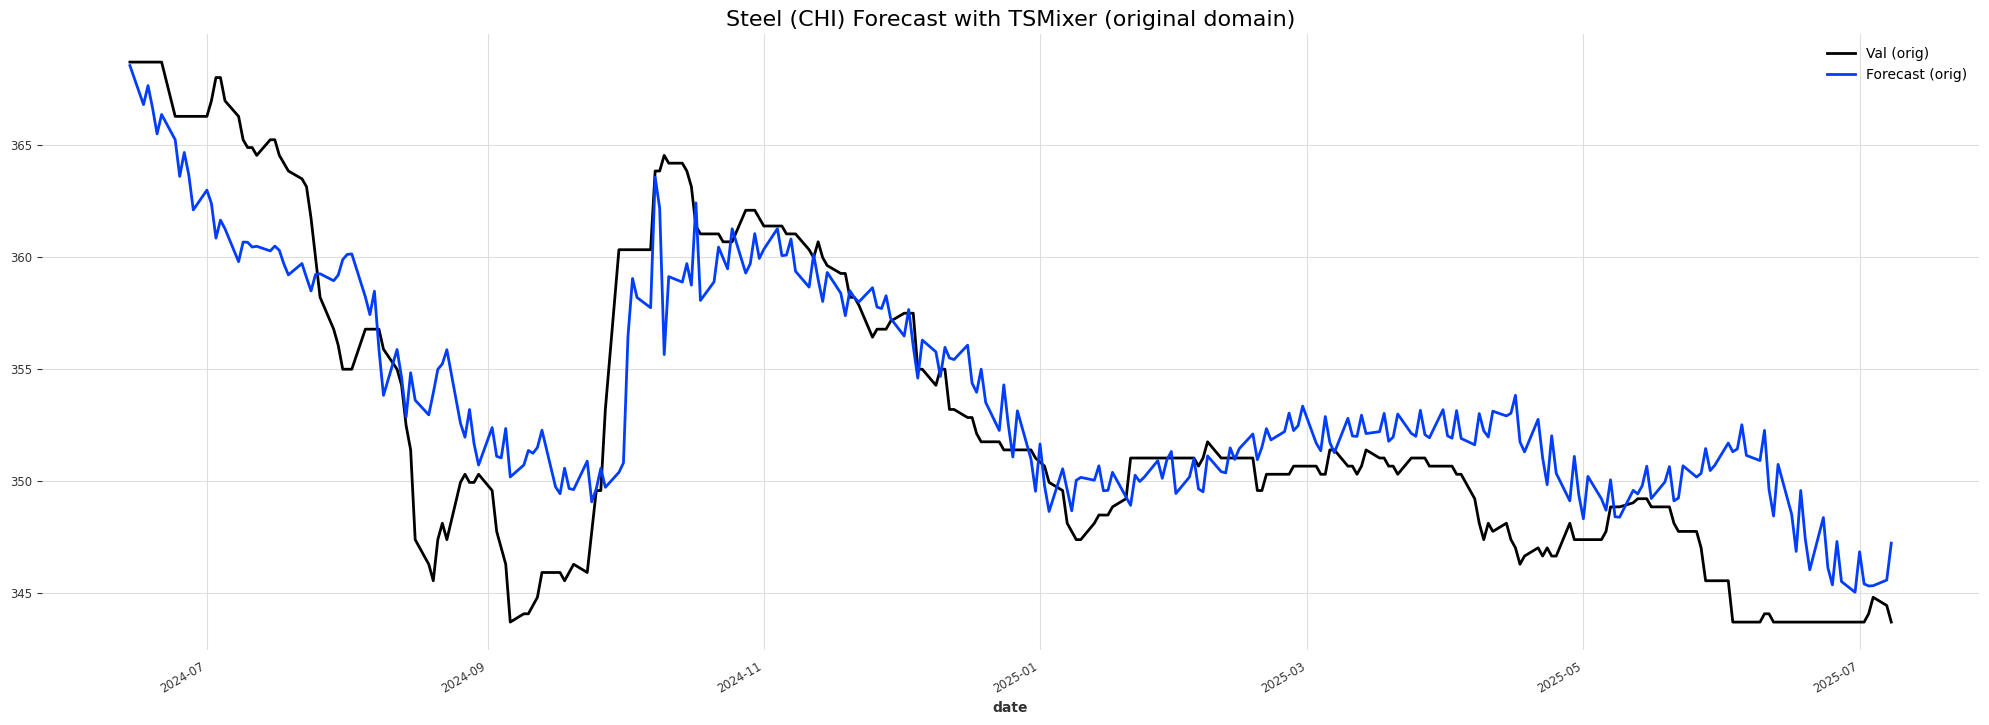

In [23]:
# ============================================
# Best run TSMixer
# ============================================

result_path = 'result/'
os.makedirs(result_path, exist_ok=True)
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
tsmixer_opt_df = pd.read_excel(excel_file_path, sheet_name='tsmixer_opt')
best = tsmixer_opt_df.iloc[0]

input_chunk_length = int(best["input_chunk_length"])
output_chunk_length = int(best["output_chunk_length"])
hidden_size = int(best["hidden_size"])
ff_size = int(best["ff_size"])
num_blocks = int(best["num_blocks"])
dropout = float(best["dropout"])
lr = float(best["lr"])
weight_decay = float(best.get("weight_decay", 0.0))
activation = best["activation"]
norm_type = best["norm_type"]
loss_name = best["loss_fn"]
loss_fn = torch.nn.MSELoss() if loss_name == "mse" else torch.nn.HuberLoss()
use_likelihood = bool(best["use_likelihood"])
likelihood = QuantileRegression(quantiles=[0.1, 0.5, 0.9]) if use_likelihood else None

covs_train_best, covs_val_best, _ = prepare_covariates_flexible(
    covariates=covariates_all,
    ref_series=series_scaled_aligned,
    train_size=train_size,
    input_chunk_length=input_chunk_length,
    scaler_covs=None,
)

stopper = EarlyStopping(monitor="val_loss", patience=25, min_delta=0.001, mode='min', verbose=False)
lr_scheduler = ReduceLROnPlateau

final_pl_kwargs = torch_kwargs.get("pl_trainer_kwargs", {}).copy()
final_pl_kwargs["callbacks"] = [stopper]

other_torch_kwargs = torch_kwargs.copy()
other_torch_kwargs.pop("pl_trainer_kwargs", None)

best_model = TSMixerModel(
    input_chunk_length=input_chunk_length,
    output_chunk_length=output_chunk_length,
    hidden_size=hidden_size,
    ff_size=ff_size,
    num_blocks=num_blocks,
    dropout=dropout,
    batch_size=32,
    n_epochs=500,
    likelihood=likelihood, 
    optimizer_kwargs={"lr": lr, "weight_decay": weight_decay},
    random_state=42,
    force_reset=True,
    save_checkpoints=True,
    activation=activation,   
    norm_type=norm_type,     
    loss_fn=loss_fn,         
    lr_scheduler_cls=lr_scheduler, 
    lr_scheduler_kwargs={"patience": 25, "factor": 0.2, "verbose": False}, 
    pl_trainer_kwargs=final_pl_kwargs, 
    **other_torch_kwargs
)

print("Training the best model TSMixer...")
start_time = time.time()

best_model.fit(
    series=train_scaled, 
    past_covariates=covs_train_best,
    val_series=val_scaled,
    val_past_covariates=covs_val_best,
    verbose=False
)

print("Predicting...")
prediction = (
    best_model.predict(n=len(val_scaled), past_covariates=covs_val_best, num_samples=300)
    if use_likelihood
    else best_model.predict(n=len(val_scaled), past_covariates=covs_val_best)
)
exec_time = round(time.time() - start_time, 4)

# Metrics
mets = metrics_on_original_domain(
    y_val_scaled=val_scaled,
    y_pred=prediction,
    y_train_scaled=train_scaled,
    scaler_target=scaler,
    reduce_to_median=True,
)

pred_point = prediction.quantile_timeseries(0.5) if getattr(prediction, "is_stochastic", False) else prediction
val_trans  = scaler.inverse_transform(val_scaled)
pred_trans = scaler.inverse_transform(pred_point)
val_orig   = inverse_transform(val_trans)
pred_orig  = inverse_transform(pred_trans)
rmsle_val  = rmsle(val_orig, pred_orig)

print("\nBest Model Metrics TSMixer:")
print(f"MAE(orig):   {mets['mae']:.4f}")
print(f"MSE(orig):   {mets['mse']:.4f}")
print(f"RMSE(orig):  {mets['rmse']:.4f}")
print(f"RMSLE(orig): {rmsle_val:.4f}")
print(f"MAPE(orig):  {mets['mape']:.4f}%")
print(f"SMAPE(orig): {mets['smape']:.4f}%")
print(f"Time:        {exec_time}s")

# ============================================
# Summary
# ============================================
sheet_name_summary = "summary_chi"
new_row = {
    'Dataset': 'Steel (CHI)',
    'Model': 'TSMixer',
    'MAE': mets['mae'],
    'MSE': mets['mse'],
    'RMSE': mets['rmse'],
    'RMSLE': rmsle_val,
    'MAPE': mets['mape'],
    'SMAPE': mets['smape'],
    'MASE': mets.get('mase', np.nan),
    'MARRE': mets['marre'],
    'Time': exec_time
}

try:
    summary_df = pd.read_excel(excel_file_path, sheet_name=sheet_name_summary)
    mask = (summary_df['Dataset'] == new_row['Dataset']) & (summary_df['Model'] == new_row['Model'])
    if mask.any():
        summary_df.loc[mask, list(new_row.keys())[2:]] = list(new_row.values())[2:]
        print(f"Updated: {new_row['Model']}")
    else:
        summary_df = pd.concat([summary_df, pd.DataFrame([new_row])], ignore_index=True)
        print(f"Add new model: {new_row['Model']}")
except FileNotFoundError:
    summary_df = pd.DataFrame([new_row])
    print("File not found, created new Summary.")
except ValueError:
    summary_df = pd.DataFrame([new_row])
    print("Sheet 'summary_chi' not found, created new one.")

with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    summary_df.to_excel(writer, sheet_name=sheet_name_summary, index=False)

# ============================================
# Errors DF
# ============================================
y_hat = pred_orig.univariate_values()
y_true = val_orig.univariate_values()

tsmixer_pred = pd.DataFrame({
    "date": pred_orig.time_index,
    "forecast": y_hat
})

tsmixer_error = pd.DataFrame({
    "date": val_orig.time_index,
    "error": np.abs(y_hat - y_true)
})

eps = 1e-12
tsmixer_smape = pd.DataFrame({
    "date": val_orig.time_index,
    "smape": 100 * (2.0 * np.abs(y_true - y_hat) / (np.abs(y_true) + np.abs(y_hat) + eps))
})

book = load_workbook(excel_file_path)
if "error_chi" in book.sheetnames:
    error_df = pd.read_excel(excel_file_path, sheet_name="error_chi")
    error_df["tsmixer_pred"]  = tsmixer_pred["forecast"].values
    error_df["tsmixer_error"] = tsmixer_error["error"].values
    error_df["tsmixer_smape"] = tsmixer_smape["smape"].values
    with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
        error_df.to_excel(writer, sheet_name="error_chi", index=False)
else:
    print("Sheet 'error_chi' not found. (Opcional: crie uma vez para consolidar erros por timestamp.)")

# ============================================
# Plot
# ============================================
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 8))
val_orig.plot(label="Val (orig)")
pred_orig.plot(label="Forecast (orig)")
plt.title("Steel (CHI) Forecast with TSMixer (original domain)", fontsize=16)
plt.legend(); plt.grid(True); plt.show()

# Ranking

In [4]:
# Calculating the scores

result_list = pd.read_excel(
    "result/dlr_result_chi.xlsx",
    sheet_name="summary_chi",
    usecols=["Model", "MAPE", "SMAPE", "MASE", "MARRE"]
)

def calc_rank(coluna):
    coluna_rank = coluna.rank(ascending=True, method='min')
    coluna_rank_max = len(coluna) + 1
    pontuacao = coluna_rank_max - coluna_rank
    return pontuacao.astype(int)

result_list['MAPE_scr'] = calc_rank(result_list['MAPE'])
result_list['SMAPE_scr'] = calc_rank(result_list['SMAPE'])
result_list['MASE_scr'] = calc_rank(result_list['MASE'])
result_list['MARRE_scr'] = calc_rank(result_list['MARRE'])

result_list['TOTAL_scr'] = result_list['MAPE_scr'] + result_list['SMAPE_scr'] + result_list['MASE_scr'] + result_list['MARRE_scr']
result_list = result_list.sort_values(by='TOTAL_scr', ascending=False)

result_path = 'result/'
excel_file_path = os.path.join(result_path, 'dlr_result_chi.xlsx')
if os.path.exists(excel_file_path):
    try:
        with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
            result_list.to_excel(writer, sheet_name='rank_chi', index=False)
    except Exception as e:
        print(f"Error adding the sheet 'rank_chi': {e}")
else:
    with pd.ExcelWriter(excel_file_path, engine='openpyxl', mode='w') as writer:
        result_list.to_excel(writer, sheet_name='rank_chi', index=False)

# VaR

In [41]:
# ==============================================================================
# Loading
# ==============================================================================
file_path = "result/dlr_result_chi.xlsx"
sheet_input = "error_chi"
sheet_output_var = "var_chi"
sheet_output_backtest = "var_chi_backtest"

df = pd.read_excel(file_path, sheet_name=sheet_input, usecols=[
    "rnn_error", "trans_error", "nhits_error", "dlinear_error", "tcn_error", "tsmixer_error"
])

# ==============================================================================
# Backtesting VaR
# ==============================================================================

def kupiec_test(actual_losses, var_forecasts, alpha):
    exceptions = actual_losses > var_forecasts
    num_exceptions = np.sum(exceptions)
    num_obs = len(actual_losses)
    
    if num_obs == 0: return {'Exceptions': 0, 'Failure Rate': 0, 'Kupiec p-value': np.nan}

    failure_rate = num_exceptions / num_obs
    expected_rate = 1 - alpha

    if num_exceptions == 0 or failure_rate == 1:
        log_likelihood_unrestricted = 0
    else:
        log_likelihood_unrestricted = (num_obs - num_exceptions) * np.log(1 - failure_rate) + num_exceptions * np.log(failure_rate)

    if num_exceptions == 0:
        log_likelihood_restricted = (num_obs - num_exceptions) * np.log(1 - expected_rate)
    else:
        log_likelihood_restricted = (num_obs - num_exceptions) * np.log(1 - expected_rate) + num_exceptions * np.log(expected_rate)
    
    lr_stat = -2 * (log_likelihood_restricted - log_likelihood_unrestricted)
    p_value = 1 - chi2.cdf(lr_stat, 1)

    return {
        'Exceptions': num_exceptions,
        'Failure Rate': round(failure_rate, 4),
        'Kupiec p-value': round(p_value, 4)
    }

# --- Function Definitions
def var_historical(errors, alpha): return np.percentile(np.abs(errors), 100 * alpha)

def var_parametric(errors, alpha):
    mean_error, std_error = np.mean(errors), np.std(errors)
    return abs(mean_error + std_error * norm.ppf(alpha))
    
def var_egarch(errors, alpha, max_val):
    model = arch_model(errors, vol='EGarch', p=1, q=1, o=1, mean='AR', dist='normal')
    res = model.fit(disp="off")
    sigma = res.conditional_volatility[-1]
    return min(abs(sigma * norm.ppf(alpha)), max_val)

def var_tgarch(errors, alpha, max_val):
    model = arch_model(errors, vol='Garch', p=1, q=1, o=1, mean='AR', dist='t')
    res = model.fit(disp="off")
    sigma = res.conditional_volatility[-1]
    df = res.params.get("nu", 10)
    return min(abs(sigma * student_t.ppf(alpha, df)), max_val)

def var_fhs(errors, alpha, max_val):
    model = arch_model(errors, vol='Garch', p=1, q=1, o=1, mean='AR', dist='t')
    res = model.fit(disp="off")
    std_resid = res.std_resid[~np.isnan(res.std_resid)]
    sigma = res.conditional_volatility[-1]
    quantile = np.percentile(std_resid, 100 * alpha)
    return min(abs(sigma * quantile), max_val)

def expected_shortfall(errors, var_value):
    losses = np.abs(errors)
    exceedances = losses[losses > var_value]
    return exceedances.mean() if len(exceedances) > 0 else var_value

def generate_rolling_var_forecasts(errors, window_size, alpha):
    T = len(errors)
    var_hist = np.zeros(T - window_size)
    var_param = np.zeros(T - window_size)
    var_tgarch = np.zeros(T - window_size)
    var_egarch = np.zeros(T - window_size)

    for i in range(window_size, T):
        window_errors = errors[i - window_size:i]

        # Historical
        var_hist[i - window_size] = var_historical(window_errors, alpha)

        # Parametric
        var_param[i - window_size] = var_parametric(window_errors, alpha)

        # tGARCH
        try:
            model_tgarch = arch_model(window_errors, vol='Garch', p=1, q=1, o=1, mean='AR', dist='t')
            res_tgarch = model_tgarch.fit(disp="off")
            sigma_tgarch = res_tgarch.forecast(horizon=1).variance.values[-1, 0] ** 0.5
            df_tgarch = res_tgarch.params.get("nu", 10)
            var_tgarch[i - window_size] = abs(sigma_tgarch * student_t.ppf(alpha, df_tgarch))
        except:
            var_tgarch[i - window_size] = np.nan

        # eGARCH
        try:
            model_egarch = arch_model(window_errors, vol='EGarch', p=1, q=1, o=1, mean='AR', dist='normal')
            res_egarch = model_egarch.fit(disp="off")
            sigma_egarch = res_egarch.forecast(horizon=1).variance.values[-1, 0] ** 0.5
            var_egarch[i - window_size] = abs(sigma_egarch * norm.ppf(alpha))
        except:
            var_egarch[i - window_size] = np.nan

    return {
        'Historical': var_hist,
        'Parametric': var_param,
        'tGARCH': var_tgarch,
        'eGARCH': var_egarch
    }

# --- Loop for Backtesting ---
confidence_levels = [0.95, 0.99]
backtest_results = []
window_size = 252

print("Executing Backtesting of VaR Models ")
for modelo in df.columns:
    print(f"Model processing: {modelo}...")
    errors = df[modelo].dropna().values
    
    if len(errors) <= window_size:
        print(f"  Warning: Too little data for the model {modelo}. Skipping backtest.")
        continue
        
    actual_losses = np.abs(errors[window_size:])

    for alpha in confidence_levels:
        var_forecasts = generate_rolling_var_forecasts(errors, window_size, alpha)
        
        bt_hist = kupiec_test(actual_losses, var_forecasts['Historical'], alpha)
        bt_param = kupiec_test(actual_losses, var_forecasts['Parametric'], alpha)
        bt_tgarch = kupiec_test(actual_losses, var_forecasts['tGARCH'], alpha)
        bt_egarch = kupiec_test(actual_losses, var_forecasts['eGARCH'], alpha)
        
        backtest_results.append({"Model": modelo, "Confidence": f"{int(alpha*100)}%", "VaR Method": "Historical", **bt_hist})
        backtest_results.append({"Model": modelo, "Confidence": f"{int(alpha*100)}%", "VaR Method": "Parametric", **bt_param})
        backtest_results.append({"Model": modelo, "Confidence": f"{int(alpha*100)}%", "VaR Method": "tGARCH", **bt_tgarch})
        backtest_results.append({"Model": modelo, "Confidence": f"{int(alpha*100)}%", "VaR Method": "eGARCH", **bt_egarch})

df_backtest = pd.DataFrame(backtest_results)

# ==============================================================================
# VaR Calculation
# ==============================================================================

def var_historical(errors, alpha):
    # VaR calculation using Historical Simulation
    return np.percentile(np.abs(errors), 100 * alpha)

def var_parametric(errors, alpha, distribution='normal', df=10):
    # VaR calculation using Variance-Covariance
    mean_error = np.mean(errors)
    std_error = np.std(errors)
    
    if distribution == 'normal':
        quantile = norm.ppf(alpha)
    elif distribution == 't':
        quantile = student_t.ppf(alpha, df)
    else:
        quantile = norm.ppf(alpha)
        
    return abs(mean_error + std_error * quantile)

def es_expected(errors, var_val):
    # Expected Shortfall Calculation (ES/CVaR)
    losses = np.abs(errors)
    exceed = losses[losses > var_val]
    return exceed.mean() if len(exceed) > 0 else var_val

def var_egarch(errors, alpha, max_val):
    # EGARCH(1,1,1) Calculation
    model = arch_model(errors, vol='EGarch', p=1, q=1, o=1, mean='AR', dist='normal')
    res = model.fit(disp="off")
    sigma = res.conditional_volatility[-1]
    return min(abs(sigma * norm.ppf(alpha)), max_val)

def var_tgarch(errors, alpha, max_val):
    # GJR-GARCH(1,1,1) calculation using distribution t
    model = arch_model(errors, vol='Garch', p=1, q=1, o=1, mean='AR', dist='t')
    res = model.fit(disp="off")
    sigma = res.conditional_volatility[-1]
    nu = res.params.get("nu", 10) # Fallback = 10 if 'nu' is not estimated
    return min(abs(sigma * student_t.ppf(alpha, nu)), max_val), nu

def calc_var_fhs(errors, alpha, max_val):
    # FHS  Calculation
    model = arch_model(errors, vol='Garch', p=1, q=1, o=1, mean='AR', dist='t')
    res = model.fit(disp="off")
    std_resid = res.std_resid[~np.isnan(res.std_resid)]
    sigma = res.conditional_volatility[-1]
    quantile = np.percentile(std_resid, 100 * alpha)
    return min(abs(sigma * quantile), max_val)

# Calculation loop
results = []
for modelo in df.columns:
    errors = df[modelo].dropna().values
    max_val = np.max(np.abs(errors))
    
    for alpha in confidence_levels:
        # VaR calculation
        var_hist = var_historical(errors, alpha)
        var_eg = var_egarch(errors, alpha, max_val)
        var_tg, nu_tg = var_tgarch(errors, alpha, max_val)
        var_fhs = calc_var_fhs(errors, alpha, max_val)
        var_param_norm = var_parametric(errors, alpha, distribution='normal')
        
        # ES Calculation
        es_hist = es_expected(errors, var_hist)
        es_eg = es_expected(errors, var_eg)
        es_tg = es_expected(errors, var_tg)
        es_fhs = es_expected(errors, var_fhs)
        es_param_norm = es_expected(errors, var_param_norm)

        results.append({
            "Model": modelo,
            "Confidence": f"{int(alpha * 100)}%",
            "VaR Historical": round(var_hist, 4),
            "VaR Parametric (Normal)": round(var_param_norm, 4), # NOVO
            "VaR eGARCH": round(var_eg, 4),
            "VaR tGARCH": round(var_tg, 4),
            "VaR FHS": round(var_fhs, 4),
            "ES (Hist)": round(es_hist, 4),
            "ES (Param. Normal)": round(es_param_norm, 4), # NOVO
            "ES (eGARCH)": round(es_eg, 4),
            "ES (tGARCH)": round(es_tg, 4),
            "ES (FHS)": round(es_fhs, 4),
            # ES/VaR calculation
            "ES/VaR Ratio (Hist)": round(es_hist / var_hist if var_hist > 0 else 0, 4),
            "ES/VaR Ratio (eGARCH)": round(es_eg / var_eg if var_eg > 0 else 0, 4),
            "ES/VaR Ratio (tGARCH)": round(es_tg / var_tg if var_tg > 0 else 0, 4),
            "ES/VaR Ratio (FHS)": round(es_fhs / var_fhs if var_fhs > 0 else 0, 4),
            "ES/VaR Ratio (Param.)": round(es_param_norm / var_param_norm if var_fhs > 0 else 0, 4),
        })

# Saving
df_result = pd.DataFrame(results)

# Deleting old sheets for safe
if os.path.exists(file_path):
    book = load_workbook(file_path)
    if sheet_output_var in book.sheetnames:
        del book[sheet_output_var]
        book.save(file_path)
    if sheet_output_backtest in book.sheetnames:
        del book[sheet_output_backtest]
        book.save(file_path)

# Adding sheets
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a') as writer:
    df_result.to_excel(writer, sheet_name=sheet_output_var, index=False)
    df_backtest.to_excel(writer, sheet_name=sheet_output_backtest, index=False)

print("Results saved!")

Executing Backtesting of VaR Models 
Model processing: trans_error...
Model processing: tsmixer_error...
Model processing: rnn_error...
Model processing: nhits_error...
Model processing: dlinear_error...
Model processing: tcn_error...
Results saved!


## Engle-Ng Test (1993)

In [42]:
file_path = "result/dlr_result_chi.xlsx"
sheet_input = "error_chi"
sheet_output = "engle_neg"

modelos = pd.read_excel(file_path, sheet_name=sheet_input, usecols=[
    "rnn_error", "trans_error", "nhits_error", "dlinear_error", "tcn_error", "tsmixer_error"
])

import statsmodels.api as sm

def engle_ng_test(errors):
    errors = pd.Series(errors).dropna()
    std_resid = (errors - errors.mean()) / errors.std()
    I_neg = (std_resid < 0).astype(int)
    resid_squared = std_resid ** 2

    X = sm.add_constant(pd.DataFrame({'I_neg': I_neg}))
    model = sm.OLS(resid_squared, X).fit()

    coef = model.params['I_neg']
    pval = model.pvalues['I_neg']

    return round(coef, 4), round(pval, 4)


engle_ng_results = []

for modelo in modelos:
    errors = df[modelo].dropna().values
    coef, pval = engle_ng_test(errors)
    engle_ng_results.append({
        "Model": modelo,
        "Coefficient I_neg": coef,
        "p-value": pval,
        "Asymmetry Detected": "Yes" if pval < 0.05 else "No"
    })

df_engle_ng = pd.DataFrame(engle_ng_results)
print(df_engle_ng)

# Saving
df_result = pd.DataFrame(df_engle_ng)

# Deleting old sheets for safe
if os.path.exists(file_path):
    book = load_workbook(file_path)
    if sheet_output in book.sheetnames:
        del book[sheet_output]
        book.save(file_path)

# Adding sheets
with pd.ExcelWriter(file_path, engine='openpyxl', mode='a') as writer:
    df_result.to_excel(writer, sheet_name=sheet_output, index=False)

print("Results saved!")

           Model  Coefficient I_neg  p-value Asymmetry Detected
0    trans_error            -1.1147    0.000                Yes
1  tsmixer_error            -1.2025    0.000                Yes
2      rnn_error            -0.4110    0.010                Yes
3    nhits_error            -0.7212    0.000                Yes
4  dlinear_error            -1.8535    0.000                Yes
5      tcn_error            -0.5612    0.001                Yes
Results saved!


# Statistics

## Statistical Tests

Shapiro-Wilk p-value (arima_error): 0.000000
Shapiro-Wilk p-value (es_error): 0.000000
Shapiro-Wilk p-value (lr_error): 0.000000
Shapiro-Wilk p-value (rnn_error): 0.000000
Shapiro-Wilk p-value (trans_error): 0.000000
Shapiro-Wilk p-value (nhits_error): 0.000000
Shapiro-Wilk p-value (tcn_error): 0.000116
Shapiro-Wilk p-value (tsmixer_error): 0.000000
Shapiro-Wilk p-value (dlinear_error): 0.000000
The errors are NOT Normal Distribution. Apply Friedman
Levene Statistics: 240.944657, p-value: 0.000000
The errors are NOT homogeneous. Apply Friedman
Friedman test statistic: 894.888249
P-value: 0.000000
There is a significant difference among the models.


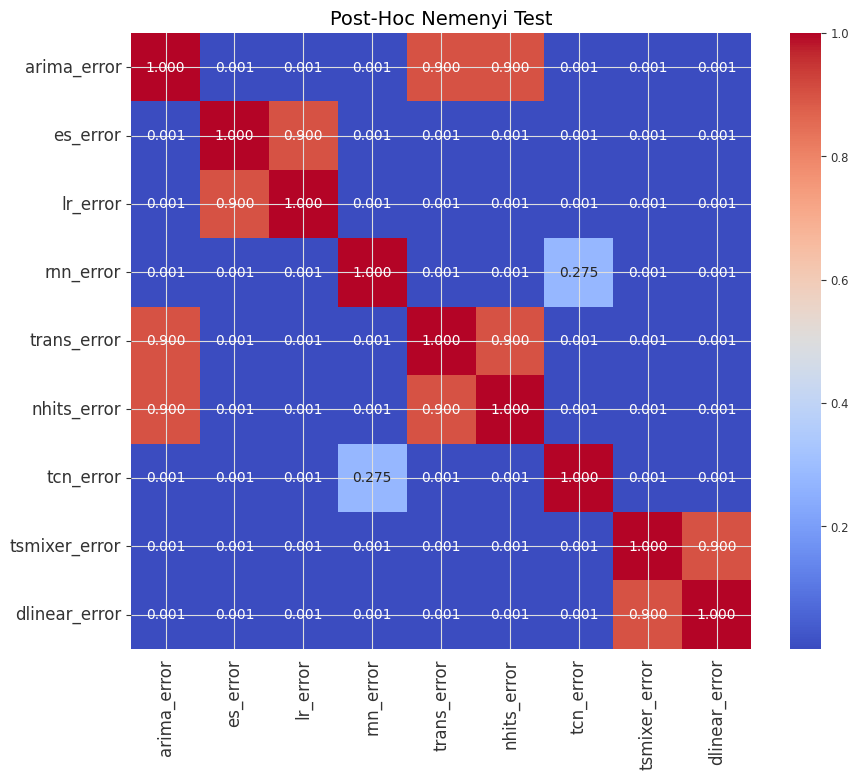

In [52]:
file_path = "result/dlr_result_chi.xlsx"
sheet_name = "error_chi"

df = pd.read_excel(file_path, sheet_name=sheet_name)

model_columns = ["arima_error", "es_error", "lr_error", "rnn_error", "trans_error", "nhits_error", "tcn_error", "tsmixer_error", "dlinear_error"]
df = df[model_columns]

# Shapiro-Wilk
p_values_shapiro = {}
for model in model_columns:
    stat, p_value = shapiro(df[model])
    p_values_shapiro[model] = p_value
    print(f"Shapiro-Wilk p-value ({model}): {p_value:.6f}")

# Friedman or ANOVA
if all(p_value >= 0.05 for p_value in p_values_shapiro.values()):
    print("The errors ARE Normal Distribution. Apply ANOVA")
    which_test = "ANOVA"
else:
    print("The errors are NOT Normal Distribution. Apply Friedman")
    which_test = "Friedman"

# Levene Test
stat, p_value = levene(*[df[col] for col in model_columns])
print(f"Levene Statistics: {stat:.6f}, p-value: {p_value:.6f}")

if p_value < 0.05:
    print("The errors are NOT homogeneous. Apply Friedman")
    which_test = "Friedman"
else:
    print("The errors ARE homogeneous. Apply ANOVA")
    which_test = "ANOVA"

# Friedman Test
if which_test == "Friedman":
    stat, p_value = friedmanchisquare(*[df[col] for col in model_columns])
    print(f"Friedman test statistic: {stat:.6f}")
    print(f"P-value: {p_value:.6f}")

    if p_value < 0.05:
        print("There is a significant difference among the models.")

        nemenyi_results = sp.posthoc_nemenyi_friedman(df.values)

        nemenyi_results.columns = model_columns
        nemenyi_results.index = model_columns

        plt.figure(figsize=(10, 8))
        ax = sns.heatmap(nemenyi_results, annot=True, cmap="coolwarm", fmt=".3f")
        plt.xticks(fontsize=12)
        plt.yticks(fontsize=12)
        plt.title("Post-Hoc Nemenyi Test", fontsize=14)
        plt.show()
    else:
        print("There is no significant difference between the models.")

else:
    print("Test to be conducted with ANOVA.")

## Critical Difference (CD) Diagram

278 instances and 9 models (SMAPE) used.
Rejecting null hypothesis that data is normal for column arima_smape (p=0.000000<0.005556)
Rejecting null hypothesis that data is normal for column es_smape (p=0.000000<0.005556)
Rejecting null hypothesis that data is normal for column lr_smape (p=0.000000<0.005556)
Rejecting null hypothesis that data is normal for column rnn_smape (p=0.000000<0.005556)
Rejecting null hypothesis that data is normal for column trans_smape (p=0.000000<0.005556)
Rejecting null hypothesis that data is normal for column nhits_smape (p=0.000000<0.005556)
Rejecting null hypothesis that data is normal for column tcn_smape (p=0.000170<0.005556)
Rejecting null hypothesis that data is normal for column tsmixer_smape (p=0.000000<0.005556)
Rejecting null hypothesis that data is normal for column dlinear_smape (p=0.000000<0.005556)
Using Levene's test for homoscedacity of non-normal data.
Rejecting null hypothesis that all variances are equal (p=0.000000<0.050000)
Using Fried

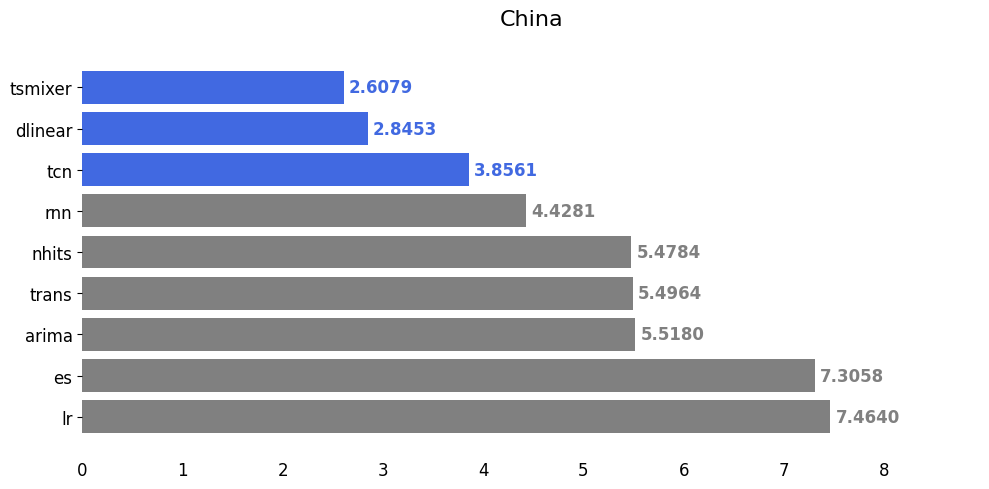

Saved in: output

== Average Ranks by SMAPE (lower is better) ==
tsmixer_smape: 2.6079
dlinear_smape: 2.8453
tcn_smape: 3.8561
rnn_smape: 4.4281
nhits_smape: 5.4784
trans_smape: 5.4964
arima_smape: 5.5180
es_smape: 7.3058
lr_smape: 7.4640


In [51]:
# ============================================================
# CD Diagram with SMAPE (autorank)
# ============================================================

# ---------------------------
# Settings
# ---------------------------
excel_file = "result/dlr_result_chi.xlsx"
sheet_errors = "error_chi"
candidate_models = ["arima", "es", "lr", "rnn", "trans", "nhits", "tcn", "tsmixer", "dlinear"]
dataset_name = "China"
output_dir = "output"
file_path = os.path.join(output_dir, f"CDD_{dataset_name}.png")

# ---------------------------
# Load and Prepare Data (SMAPE)
# ---------------------------
df = pd.read_excel(excel_file, sheet_name=sheet_errors)
smape_cols_all = [c for c in df.columns if c.endswith("_smape")]

smape_cols = []
for m in candidate_models:
    col = f"{m}_smape"
    if col in smape_cols_all:
        smape_cols.append(col)

assert len(smape_cols) >= 3

# Instances × models matrix (numeric and without NaN)
X = df[smape_cols].apply(pd.to_numeric, errors="coerce").dropna(how="any")
n_instances, k_models = X.shape
print(f"{n_instances} instances and {k_models} models (SMAPE) used.")

# ---------------------------
# AUTORANK (Friedman + Nemenyi + CD plot)
# ---------------------------
results = autorank(-X, alpha=0.05, verbose=True)

# ---------------------------
# Ranks per instance and average ranks (lowest SMAPE ⇒ rank 1)
# ---------------------------
ranks_df = X.apply(
    lambda row: pd.Series(rankdata(row.values, method="average")),
    axis=1
)
ranks_df.columns = X.columns

avg_ranks = (
    ranks_df.mean(axis=0)
    .sort_values()
    .reset_index()
    .rename(columns={"index": "model", 0: "avg_rank"})
)

# ---------------------------
# Plot
# ---------------------------

avg_ranks_plot = avg_ranks.copy()
avg_ranks_plot['model'] = avg_ranks_plot['model'].str.replace('_smape', '')
avg_ranks_sorted = avg_ranks_plot.sort_values(by='avg_rank', ascending=True)

colors = ['royalblue' if i < 3 else 'gray' for i in range(len(avg_ranks_sorted))]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    avg_ranks_sorted['model'],
    avg_ranks_sorted['avg_rank'],
    color=colors
)
ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'{width:.4f}',
        va='center',
        ha='left',
        fontsize=12,
        fontweight='bold',
        color=bar.get_facecolor()
    )

ax.set_title(dataset_name, fontsize=16, pad=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.grid(False)
ax.tick_params(axis='x', colors='black', labelsize=12)
ax.tick_params(axis='y', colors='black', labelsize=12)
ax.set_xlim(right=avg_ranks_sorted['avg_rank'].max() * 1.20)
plt.tight_layout()

# Saving
plt.savefig(file_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved in: {output_dir}")

# ---------------------------
# 5) Summary
# ---------------------------
print("\n== Average Ranks by SMAPE (lower is better) ==")
for _, row in avg_ranks.iterrows():
    print(f"{row['model']}: {row['avg_rank']:.4f}")

## Correlation Matrix

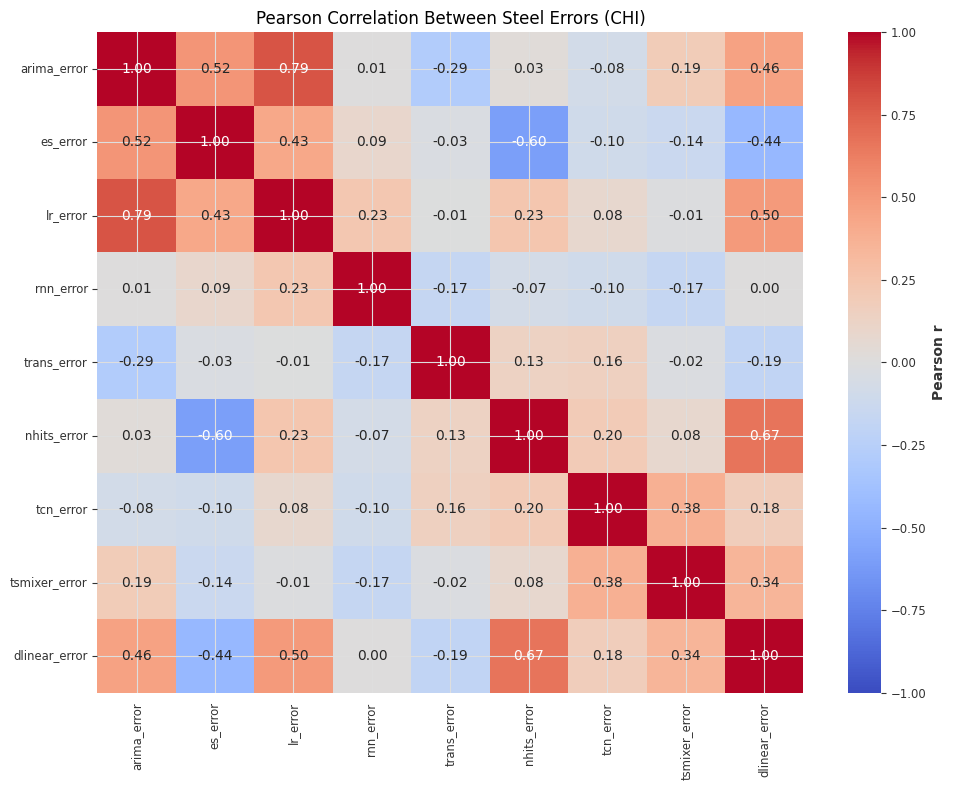

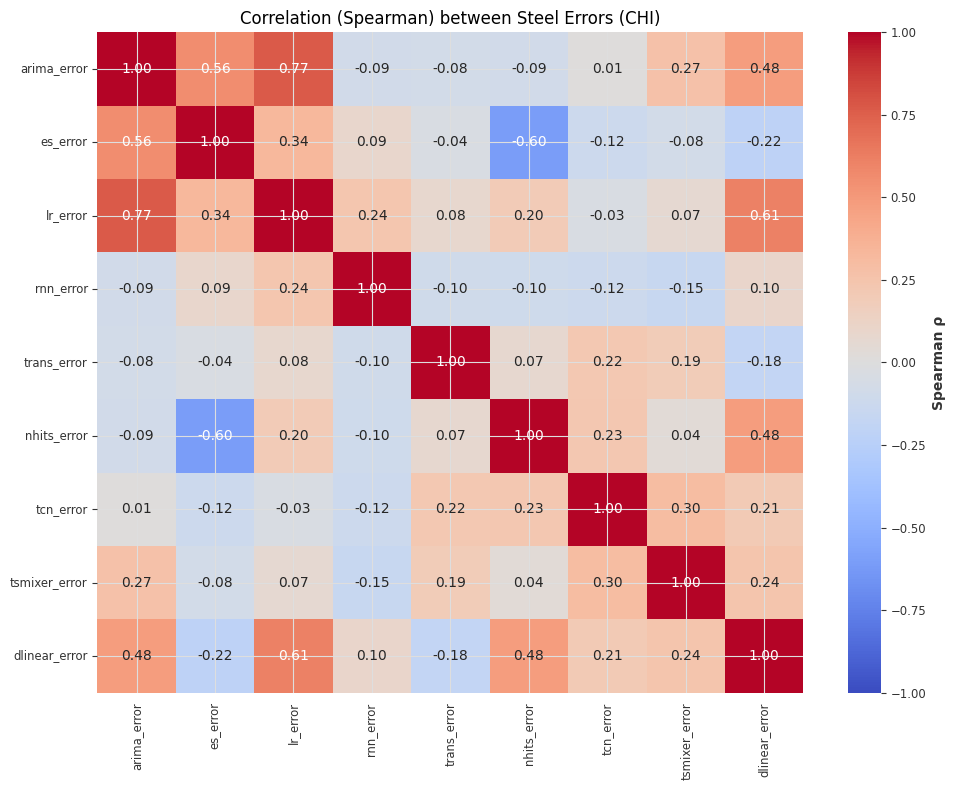

In [54]:
# ===========================================
# Correlation between errors (Pearson/Spearman)
# ===========================================

file_path = "result/dlr_result_chi.xlsx"
sheet_name = "error_chi"
df_err = pd.read_excel(file_path, sheet_name=sheet_name)
output_dir = "output"
file_pearson = os.path.join(output_dir, f"corr_pearson{dataset_name}.png")
file_spearman = os.path.join(output_dir, f"corr_spearman{dataset_name}.png")

model_columns = [
    "arima_error", "es_error", "lr_error",
    "rnn_error", "trans_error", "nhits_error",
    "tcn_error", "tsmixer_error", "dlinear_error"
]
model_columns = [c for c in model_columns if c in df_err.columns]
X = df_err[model_columns].copy().dropna(how="any")

# Pearson (linear)
corr_pearson = X.corr(method="pearson")
plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f",
            cbar_kws={"label": "Pearson r"})
plt.title("Pearson Correlation Between Steel Errors (CHI)")
plt.tight_layout()
plt.savefig(file_pearson, dpi=300, bbox_inches='tight')
plt.show()

# Spearman (for outliers)
corr_spearman = X.corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f",
            cbar_kws={"label": "Spearman ρ"})
plt.title("Correlation (Spearman) between Steel Errors (CHI)")
plt.tight_layout()
plt.savefig(file_spearman, dpi=300, bbox_inches='tight')
plt.show()
